Off lattice MC simulation

In [17]:
#%load_ext line_profiler

In [1]:
from numba import njit
import numpy as np
import math 
import matplotlib.pyplot as plt

PARAMETERS

In [2]:
sizes = [4.95, 5.05, 5.13, 5.22, 5.35, 5.5, 5.7, 6, 6.72, 7.2, 7.7, 8.5]
N = 100  # Number of particles

# Lennard-Jones parameters 
sigma = 1.0 
epsilon = 1.0  


T_star_high = 2.0  # Reduced temperature (above critical temperature)
T_star_low = 0.9  # Reduced temperature (below critical temperature)
T_high = T_star_high * epsilon 
T_low = T_star_low * epsilon
k_B = 1.0  # Boltzmann constant

FUNCTIONS

In [3]:
# Lennard-Jones potential (truncated)
@njit
def lennard_jones_potential(r, sigma_cut):
    if (r < sigma_cut) and r != 0:
        sr6 = (sigma / r) ** 6
        sr12 = (sigma / r) ** 12
        return 4 * epsilon * (sr12 - sr6)
    else: 
        return 0.0 


# To find easily distances between specific particles, a matrix of distances 
@njit
def initialize_distances(positions, box_length):
    distances = np.zeros((N, N)) 
    
    for i in range(N): #da zero a N - 1 
        for j in range(i + 1, N):
            drij = positions[i] - positions[j]
            drij = drij - np.round(drij / box_length) * box_length
            distances[i, j] = distances[j, i] = np.sqrt(drij[0]**2 + drij[1]**2 + drij[2]**2)
    return distances

# UPDATE DISTANCES: 
#def update_distances(positions, distances, moved_index, box_length):
#    drij = positions[moved_index] - positions # calcola la differenza tra il punto moved-index e tutti gli altri compreso se stesso
#    # è un array bidimensionale in cui ogni riga rappresenta un vettore differenza tra il punto moved index  un altro elemento
#    drij = drij - np.round(drij / box_length) * box_length
#    new_dist = np.sqrt(np.sum(drij**2, axis=1))
#    distances[moved_index,:] = new_dist
#    distances[:, moved_index] = new_dist
#    distances[moved_index, moved_index] = 0
#    return distances

@njit
def update_distances(positions, distances, moved_index, box_length):
    for i in range(N):
        if i != moved_index:
            drij = positions[moved_index] - positions[i]
            drij = drij - np.round(drij / box_length) * box_length
            distances[moved_index, i] = distances[i, moved_index] = np.sqrt(drij[0]**2 + drij[1]**2 + drij[2]**2)
    return distances


def equation_state(rho, vir, box_length, T):
    rho = N / (box_length**3)
    P = k_B * T * rho - vir / (3 * box_length**3)
    return P    

function that tries to displace a randomly picked particle and uses metropolis test

In [17]:
@njit
def displace(energy, positions, distances, beta, box_length, sigma_cut):
    attempted = 0
    passed = 0
    beta_low = 1 / T_low
    beta_high = 1 / T_high
    rho = N / (box_length**3)
    for _ in range(N):  
        j = np.random.randint(0, N-1)  # randomly picked particle
        old_position = positions[j].copy()

        # Before displacemnt, I calculate the energy of the particles that are involved with lennard jones
        old_energy = 0.0
        for i in range(N):
            if i != j:
                old_energy += lennard_jones_potential(distances[j, i], sigma_cut)
        #old_energy = np.sum([lennard_jones_potential(d, sigma_cut) for d in distances[j,:] if d < sigma_cut])
        
        # Displacement is proposed according to the density 
        if beta == beta_low:
            if (rho >= 0.75):  
                displacement = np.random.uniform(-0.15, 0.15, size=3) # (dx, dy, dz)
            elif (rho < 0.75 and rho >= 0.3):
                displacement = np.random.uniform(-0.25, 0.25, size=3) # (dx, dy, dz)
            elif (rho < 0.3 and rho > 0.2):
                displacement = np.random.uniform(-0.45, 0.45, size=3)
            elif (rho <= 0.2):
                displacement = np.random.uniform(-0.6, 0.6, size=3)

        else:
            if (rho >= 0.75):  
                displacement = np.random.uniform(-0.15, 0.15, size=3) 
            elif (rho < 0.75 and rho >= 0.35):
                displacement = np.random.uniform(-0.35, 0.35, size=3) 
            elif (rho < 0.35 and rho > 0.2):
                displacement = np.random.uniform(-1, 1, size=3)  
            elif (rho <= 0.2):
                displacement = np.random.uniform(-1.5, 1.5, size=3)    
            
        #print(f"Spostamento proposto: {displacement}")
        positions[j] = positions[j] + displacement # (x + dx, y + dy, z + dz)
        # pbc
        positions[j] =  positions[j] - np.floor(positions[j] / box_length) * box_length
    
        #print(f"Nuova posizione particella {j}: {positions[j]}")

        # Update only distances that involve the shifted particle
        #print("Distanze prima dell'aggiornamento:", distances)
        distances = update_distances(positions, distances, j, box_length)
        #print("Distanze dopo l'aggiornamento:", distances)
    
        # Calcola energia dopo lo spostamento
        new_energy = 0.0
        #new_energy = np.sum([lennard_jones_potential(d, sigma_cut) for d in distances[j, :] if d < sigma_cut])
        for i in range(N):
            if i != j:
                new_energy += lennard_jones_potential(distances[j, i], sigma_cut)

        delta_E = new_energy - old_energy
    
    #print(f"Delta E: {delta_E}, Exp(-beta * Delta E): {np.exp(-beta * delta_E)}")
        attempted += 1
    
    # Metropolis
        if delta_E <= 0 or np.random.rand() <= np.exp(-beta * delta_E):
            passed += 1 # increment passed counter
            energy = energy + delta_E # update energy 
        else:
            positions[j] = old_position  # Go back to the original position before the shift
            distances = update_distances(positions, distances, j, box_length)  # Distances are restored as before the shift
            # energy = energy does not change
    return positions, distances, energy, passed, attempted # No change in the energy, so no deltaE

#%lprun -f displace displace(positions, distances, beta, box_length, sigma_cut)

function that executes the simulation: N diplacements are attempted, acceptance rate is computed, energy is calculated 

In [5]:
# Main simulation

def run_simulation(T, steps, box_length, sigma_cut):
    total_energy = 0
    beta = 1 / (k_B * T)
    energies = []

    # Simulation starts with initial configuration of particles and initial distances among them
    positions = np.random.uniform(0, box_length, size=(N, 3))
    distances = initialize_distances(positions, box_length)
    # initial total energy of the configuration
    for i in range(N):
        for j in range(i + 1, N):
            total_energy += lennard_jones_potential(distances[i, j], sigma_cut) 

    for step in range(steps):    
        positions, distances, total_energy, passed, attempted = displace(total_energy, positions, distances, beta, box_length, sigma_cut)
        
        energies.append(total_energy)

        print(f"Passo {step+1}/{steps}, Energia: {total_energy:.3f}, Accettazione: {passed / attempted:.2f}")
        if step % 500 == 0 and step != 0:  
            print(f"distances  {distances}")
        #print(f"passo {step+1}/{steps}")
    return  energies, distances, positions

@njit
def virial(distances, sigma_cut):
        vir = 0.0
        for i in range(N):
            for j in range(i+1, N):
                if distances[i,j] < sigma_cut:
                    sr6 = (sigma / distances[i,j]) ** 6
                    sr12 = sr6 ** 2
                    Fij = 24 * epsilon * (-2 * sr12 + sr6) / distances[i,j]
                    f = Fij * distances[i,j]
                    vir += f
        return vir

@njit
# More evolution after equilibration
def continue_simu_P_mean(positions, distances, T, steps, box_length, sigma_cut):
    total_energy = 0
    virials = np.zeros(steps) # preallocate array for virials
    beta = 1 / (k_B * T)
    
    # energy of the last configuration of the run_simulation
    for i in range(N):
        for j in range(i + 1, N):
            total_energy += lennard_jones_potential(distances[i, j], sigma_cut)
    
    for step in range(steps): # the system evolves from the last configur of the run_simulation    
        positions, distances, energy, passed, attempted = displace(total_energy, positions, distances, beta, box_length, sigma_cut)
        vir = virial(distances, sigma_cut)
        virials[step] = vir # storing the value of the virial for each step 
        print(f"passo {step+1}/{steps}")
    return virials

plot functions

In [6]:
def plot_energy(energies):
    steps = len(energies)
    plt.figure(figsize=(10, 6))
    plt.plot(range(steps), energies, label='Energia totale', color='blue')
    plt.ylim(-600, 200)
    plt.xlabel("Passi")
    plt.ylabel("Energia")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

def plot_positions_with_projections(positions, box_length):
    """
    Plotta le posizioni delle particelle in 3D con le proiezioni 2D sui piani XY, XZ, YZ.
    
    Args:
        positions (numpy.ndarray): Array delle posizioni (Nx3).
        box_length (float): Lunghezza del box in ciascuna dimensione.
    """
    fig = plt.figure(figsize=(14, 10))

    # Plot 3D
    ax3d = fig.add_subplot(221, projection='3d')
    x = positions[:, 0]
    y = positions[:, 1]
    z = positions[:, 2]

    ax3d.scatter(x, y, z, c='b', marker='o', s=50, label='Particelle')
    ax3d.set_xlim([0, box_length])
    ax3d.set_ylim([0, box_length])
    ax3d.set_zlim([0, box_length])
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_title('Posizioni 3D')
    ax3d.legend()

    # Proiezione XY
    ax_xy = fig.add_subplot(222)
    ax_xy.scatter(x, y, c='r', marker='o', s=50, label='Proiezione XY')
    ax_xy.set_xlim([0, box_length])
    ax_xy.set_ylim([0, box_length])
    ax_xy.set_xlabel('X')
    ax_xy.set_ylabel('Y')
    ax_xy.set_title('Proiezione XY')
    ax_xy.legend()
    ax_xy.grid()

    # Proiezione XZ
    ax_xz = fig.add_subplot(223)
    ax_xz.scatter(x, z, c='g', marker='o', s=50, label='Proiezione XZ')
    ax_xz.set_xlim([0, box_length])
    ax_xz.set_ylim([0, box_length])
    ax_xz.set_xlabel('X')
    ax_xz.set_ylabel('Z')
    ax_xz.set_title('Proiezione XZ')
    ax_xz.legend()
    ax_xz.grid()

    # Proiezione YZ
    ax_yz = fig.add_subplot(224)
    ax_yz.scatter(y, z, c='m', marker='o', s=50, label='Proiezione YZ')
    ax_yz.set_xlim([0, box_length])
    ax_yz.set_ylim([0, box_length])
    ax_yz.set_xlabel('Y')
    ax_yz.set_ylabel('Z')
    ax_yz.set_title('Proiezione YZ')
    ax_yz.legend()
    ax_yz.grid()

    plt.tight_layout()
    plt.show()


Passo 1/2000, Energia: 12324032662.699, Accettazione: 0.50
Passo 2/2000, Energia: 35105319.886, Accettazione: 0.50
Passo 3/2000, Energia: 572398.315, Accettazione: 0.48
Passo 4/2000, Energia: 127159.609, Accettazione: 0.47
Passo 5/2000, Energia: 65708.570, Accettazione: 0.50
Passo 6/2000, Energia: 13115.093, Accettazione: 0.41
Passo 7/2000, Energia: 10695.226, Accettazione: 0.41
Passo 8/2000, Energia: 5861.524, Accettazione: 0.42
Passo 9/2000, Energia: 3464.900, Accettazione: 0.35
Passo 10/2000, Energia: 1834.645, Accettazione: 0.43
Passo 11/2000, Energia: 1373.979, Accettazione: 0.36
Passo 12/2000, Energia: 716.549, Accettazione: 0.42
Passo 13/2000, Energia: 574.825, Accettazione: 0.29
Passo 14/2000, Energia: 441.063, Accettazione: 0.42
Passo 15/2000, Energia: 275.696, Accettazione: 0.30
Passo 16/2000, Energia: 148.157, Accettazione: 0.37
Passo 17/2000, Energia: 102.159, Accettazione: 0.31
Passo 18/2000, Energia: 32.941, Accettazione: 0.34
Passo 19/2000, Energia: -21.220, Accettazione

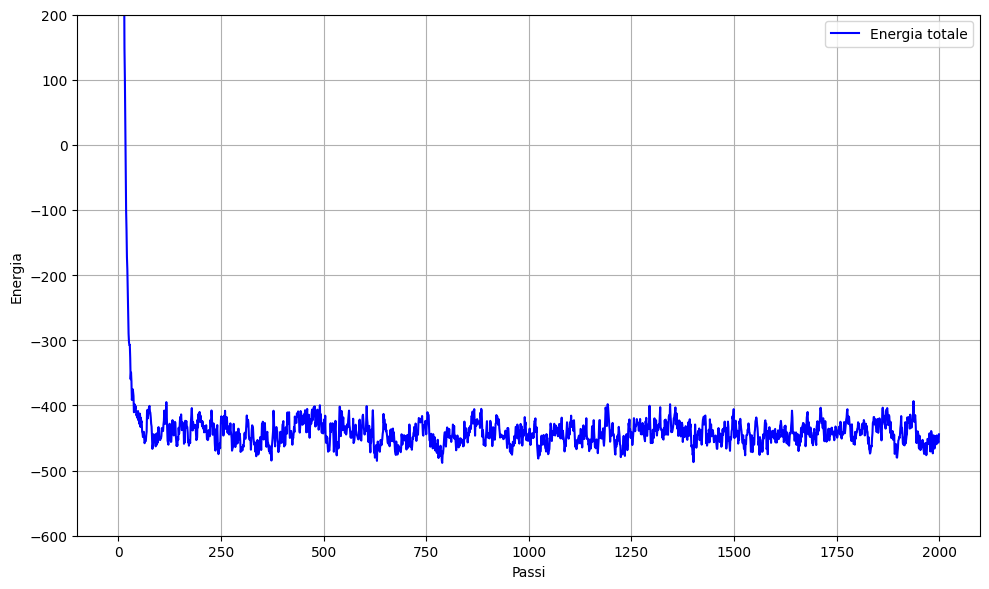

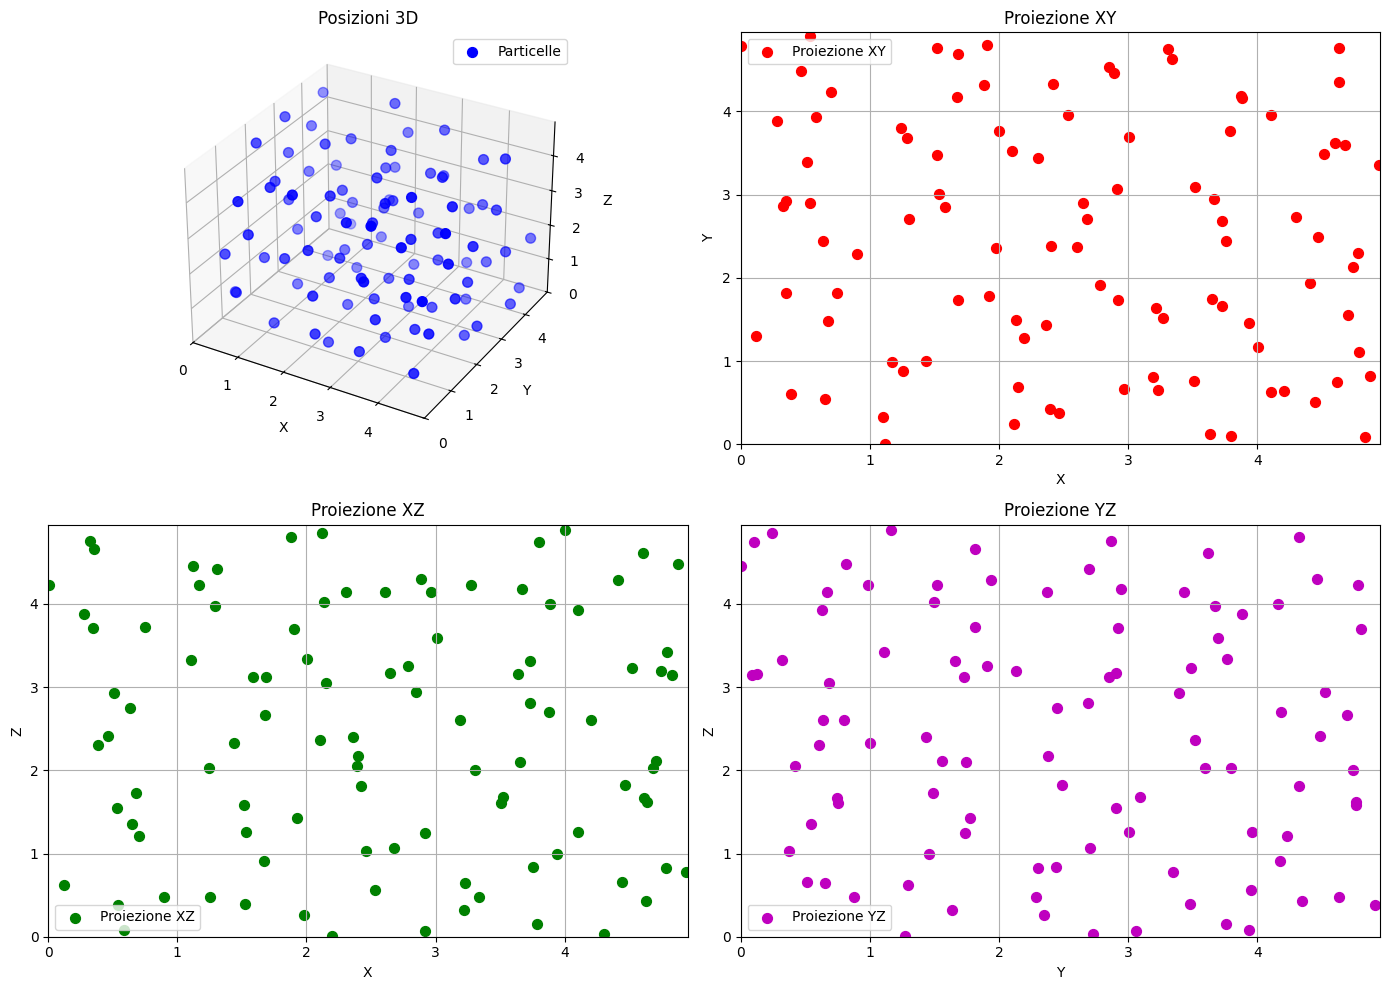

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

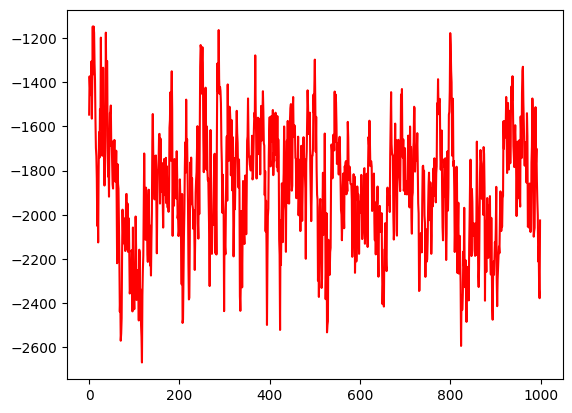

pressione senza tail  6.802630471161745
pressione con tail  6.053546782575448
Passo 1/2000, Energia: 2310854321.237, Accettazione: 0.54
Passo 2/2000, Energia: 26746108.468, Accettazione: 0.55
Passo 3/2000, Energia: 2054140.779, Accettazione: 0.44
Passo 4/2000, Energia: 652906.303, Accettazione: 0.39
Passo 5/2000, Energia: 637525.132, Accettazione: 0.48
Passo 6/2000, Energia: 471886.132, Accettazione: 0.51
Passo 7/2000, Energia: 30995.421, Accettazione: 0.40
Passo 8/2000, Energia: 8234.899, Accettazione: 0.40
Passo 9/2000, Energia: 3029.251, Accettazione: 0.37
Passo 10/2000, Energia: 1843.126, Accettazione: 0.42
Passo 11/2000, Energia: 1193.361, Accettazione: 0.24
Passo 12/2000, Energia: 658.836, Accettazione: 0.42
Passo 13/2000, Energia: 504.183, Accettazione: 0.37
Passo 14/2000, Energia: 400.223, Accettazione: 0.32
Passo 15/2000, Energia: 283.514, Accettazione: 0.39
Passo 16/2000, Energia: 100.479, Accettazione: 0.45
Passo 17/2000, Energia: 17.199, Accettazione: 0.42
Passo 18/2000, En

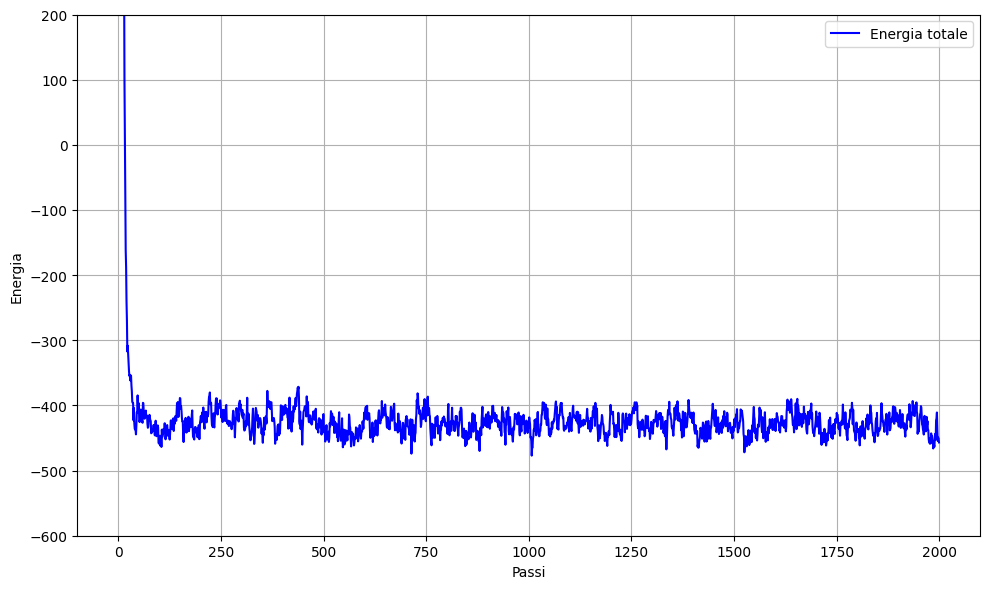

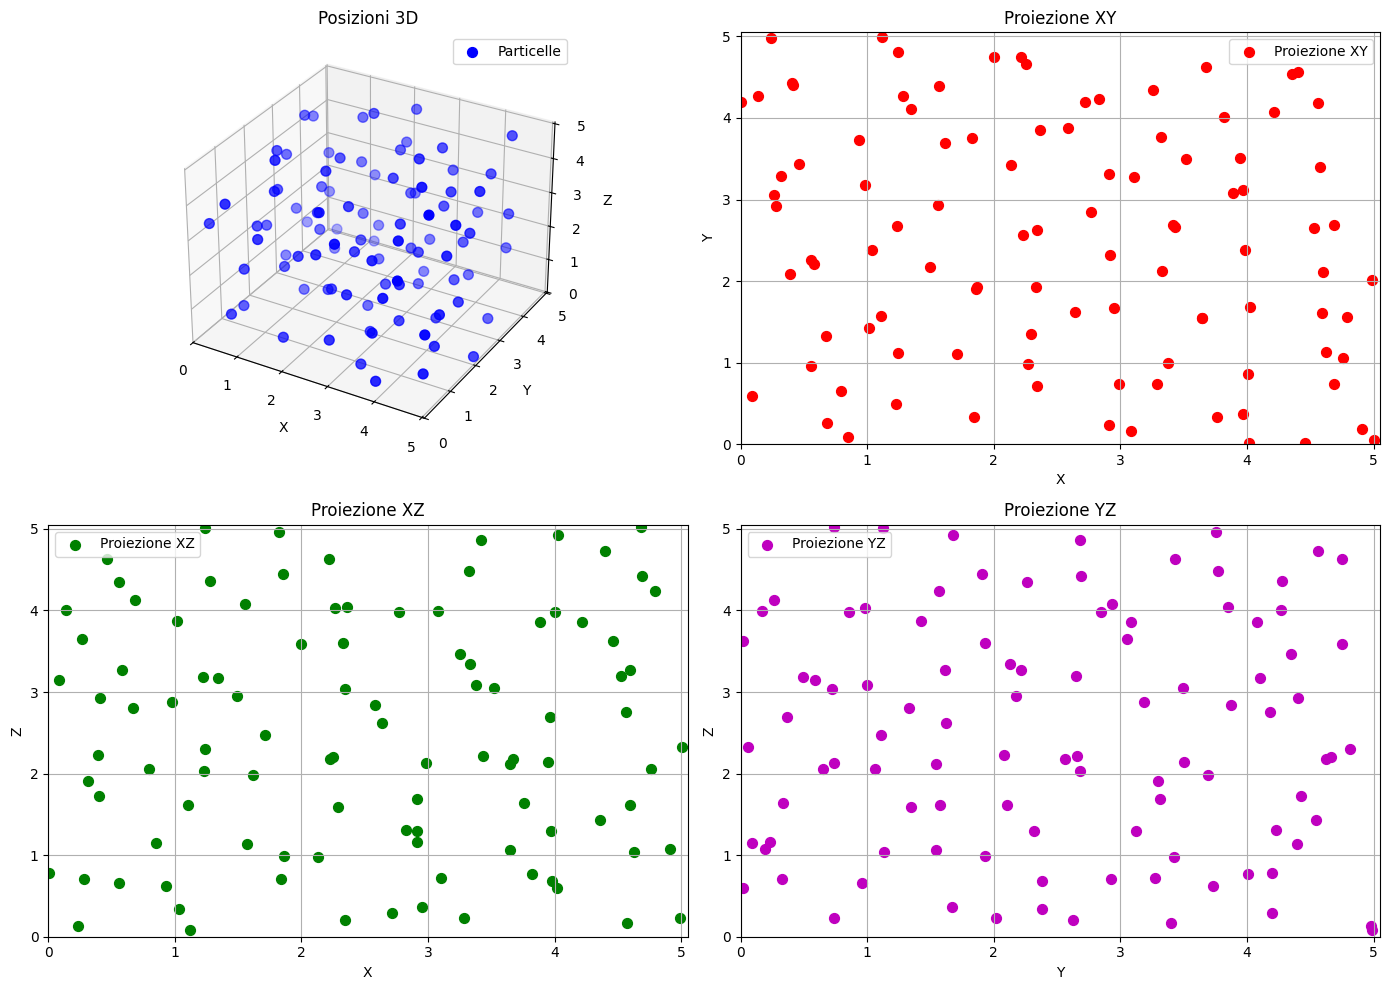

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

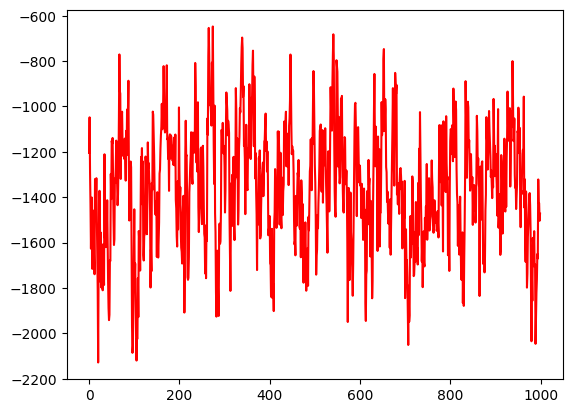

pressione senza tail  5.059581520115891
pressione con tail  4.433692171162646
Passo 1/2000, Energia: 24538051.187, Accettazione: 0.40
Passo 2/2000, Energia: 2116827.296, Accettazione: 0.45
Passo 3/2000, Energia: 483479.911, Accettazione: 0.39
Passo 4/2000, Energia: 461118.764, Accettazione: 0.38
Passo 5/2000, Energia: 20420.196, Accettazione: 0.29
Passo 6/2000, Energia: 5902.257, Accettazione: 0.24
Passo 7/2000, Energia: 3409.682, Accettazione: 0.26
Passo 8/2000, Energia: 1396.096, Accettazione: 0.23
Passo 9/2000, Energia: 1090.484, Accettazione: 0.16
Passo 10/2000, Energia: 372.626, Accettazione: 0.22
Passo 11/2000, Energia: 218.996, Accettazione: 0.13
Passo 12/2000, Energia: 99.199, Accettazione: 0.18
Passo 13/2000, Energia: 0.024, Accettazione: 0.16
Passo 14/2000, Energia: -99.030, Accettazione: 0.18
Passo 15/2000, Energia: -143.971, Accettazione: 0.27
Passo 16/2000, Energia: -157.485, Accettazione: 0.25
Passo 17/2000, Energia: -188.962, Accettazione: 0.15
Passo 18/2000, Energia: -2

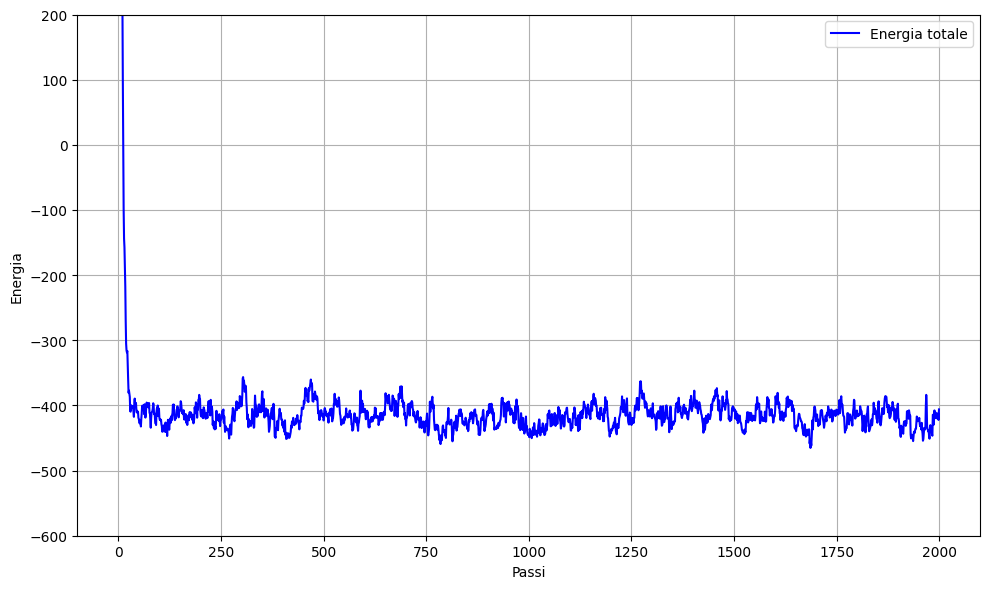

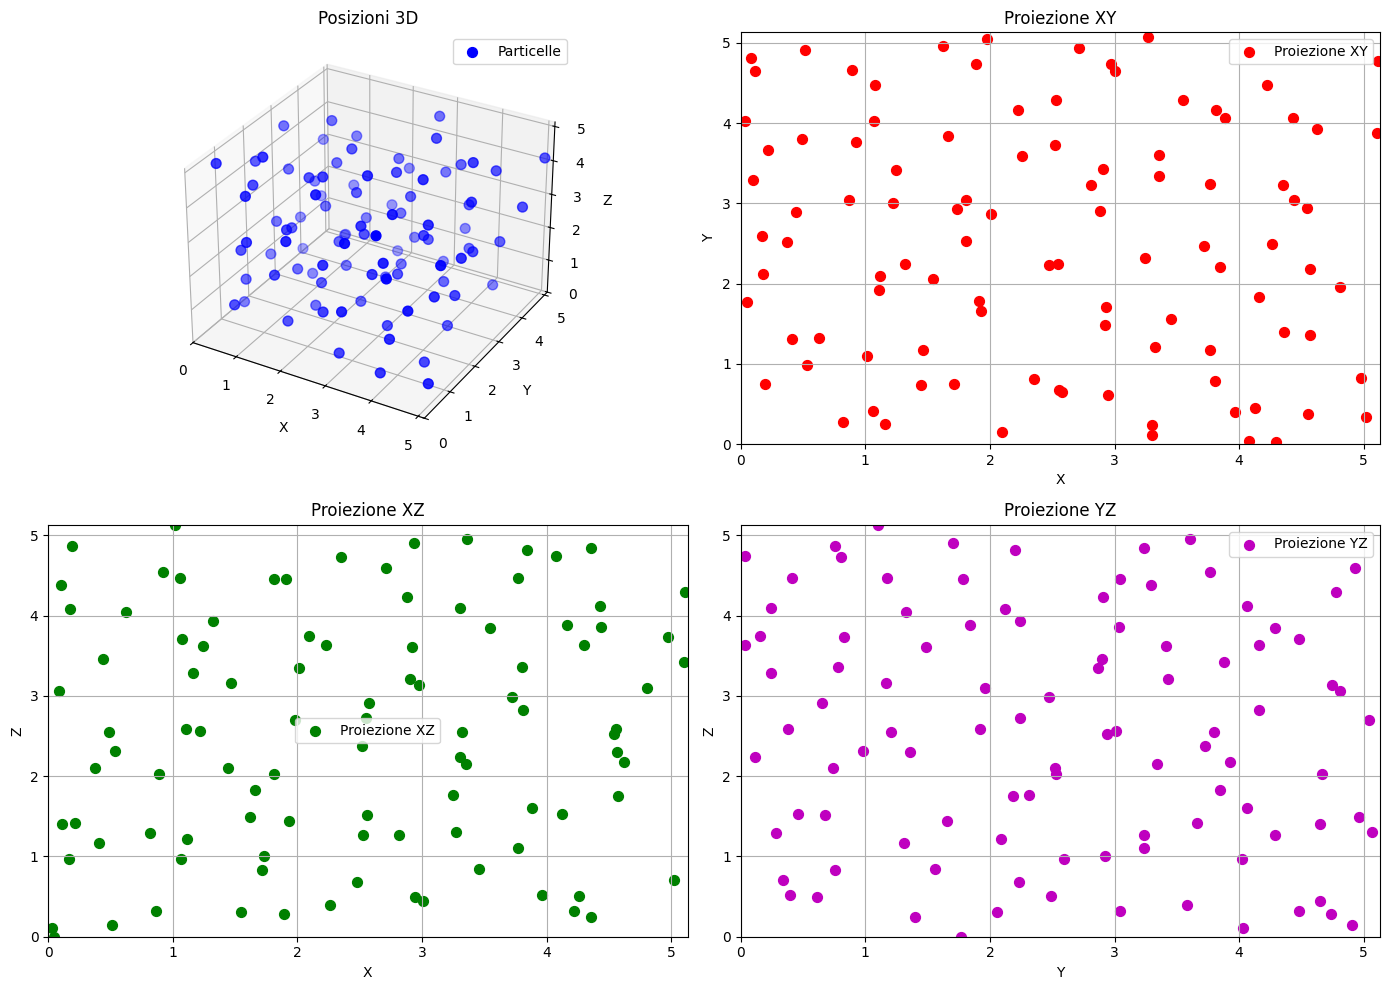

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

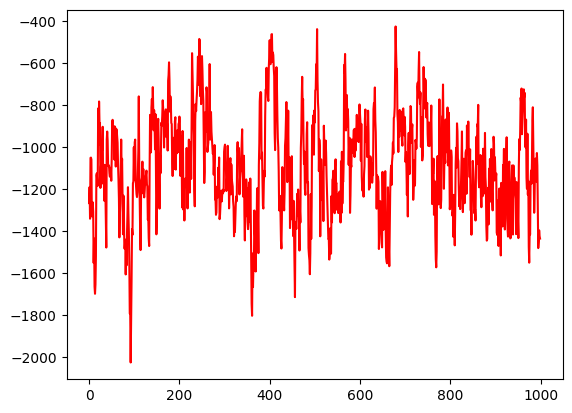

pressione senza tail  4.17578829674927
pressione con tail  3.632332199079262
Passo 1/2000, Energia: 29938669.245, Accettazione: 0.45
Passo 2/2000, Energia: 425611.914, Accettazione: 0.44
Passo 3/2000, Energia: 105614.881, Accettazione: 0.30
Passo 4/2000, Energia: 29551.972, Accettazione: 0.46
Passo 5/2000, Energia: 23611.234, Accettazione: 0.28
Passo 6/2000, Energia: 14110.682, Accettazione: 0.21
Passo 7/2000, Energia: 13686.836, Accettazione: 0.19
Passo 8/2000, Energia: 10289.697, Accettazione: 0.25
Passo 9/2000, Energia: 3735.113, Accettazione: 0.27
Passo 10/2000, Energia: 2845.839, Accettazione: 0.27
Passo 11/2000, Energia: 1209.473, Accettazione: 0.17
Passo 12/2000, Energia: 407.208, Accettazione: 0.27
Passo 13/2000, Energia: 125.884, Accettazione: 0.24
Passo 14/2000, Energia: 16.430, Accettazione: 0.22
Passo 15/2000, Energia: -203.332, Accettazione: 0.24
Passo 16/2000, Energia: -198.113, Accettazione: 0.14
Passo 17/2000, Energia: -223.348, Accettazione: 0.17
Passo 18/2000, Energia

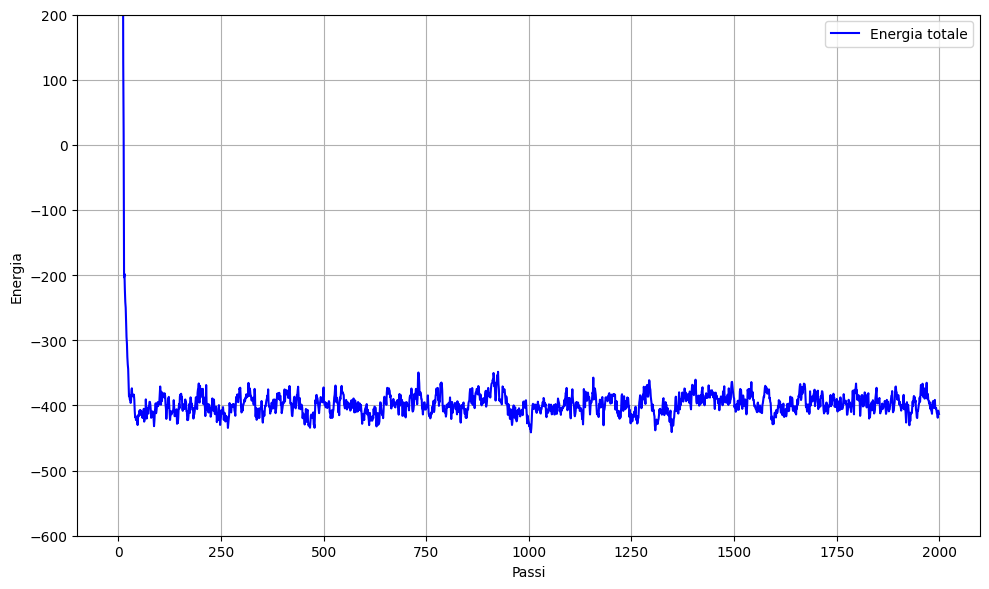

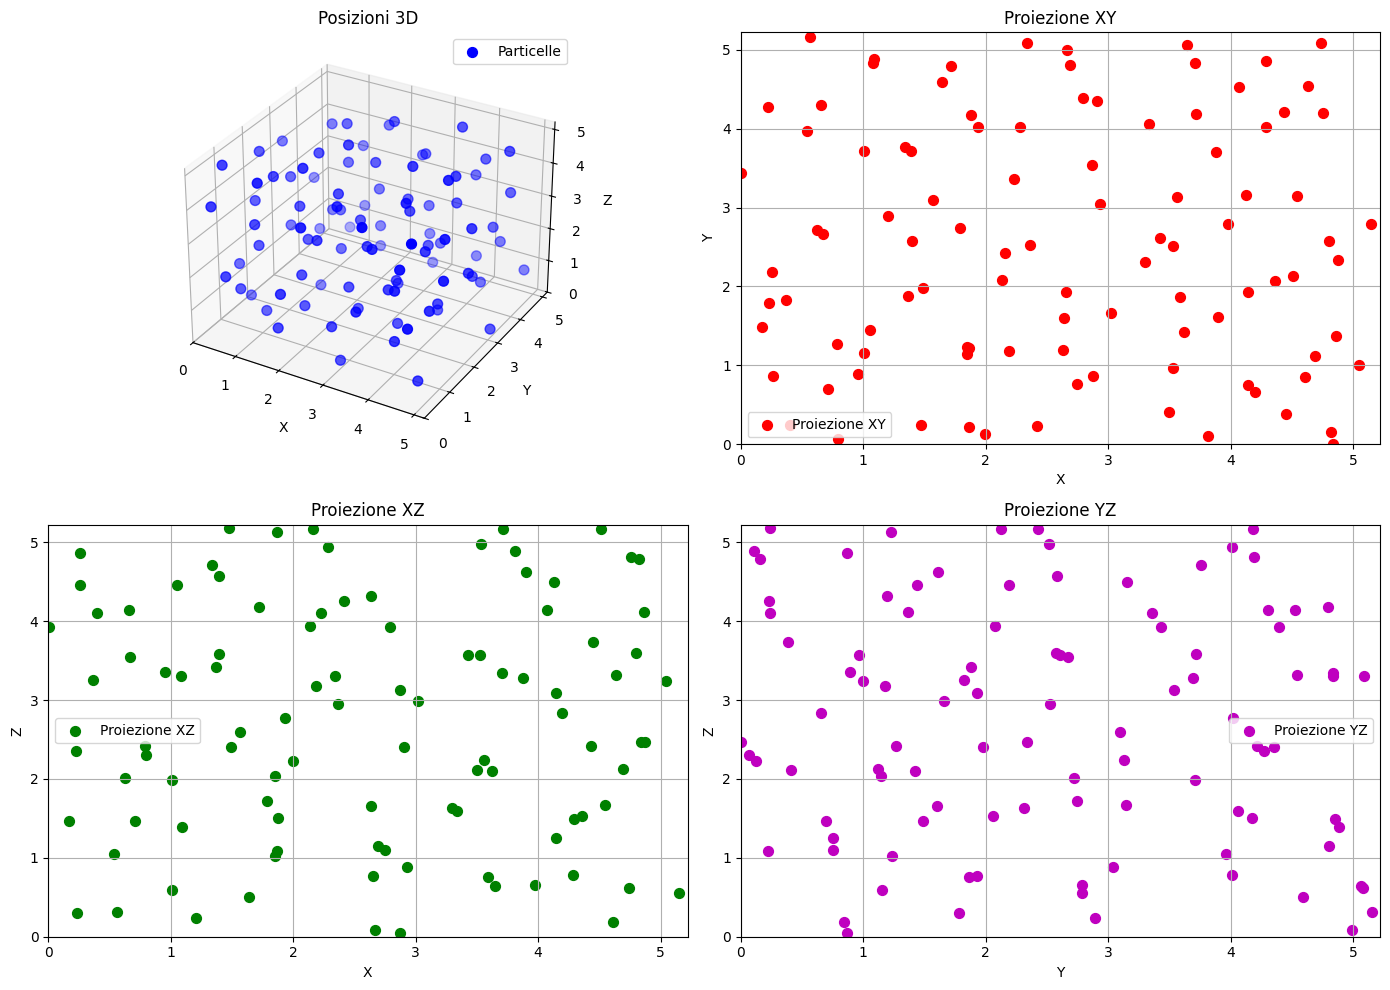

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

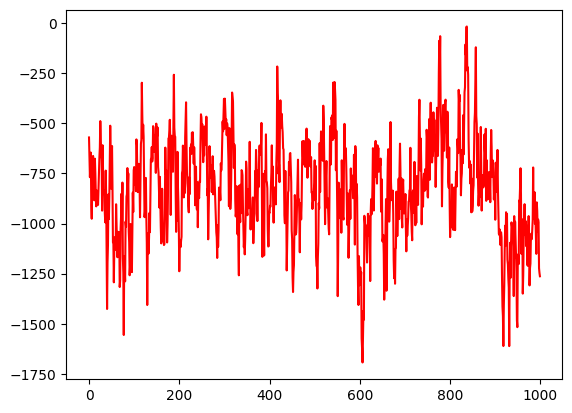

pressione senza tail  3.3557312491478597
pressione con tail  2.8909086986624595
Passo 1/2000, Energia: 6416001.543, Accettazione: 0.41
Passo 2/2000, Energia: 102987.375, Accettazione: 0.50
Passo 3/2000, Energia: 46411.303, Accettazione: 0.26
Passo 4/2000, Energia: 35734.396, Accettazione: 0.34
Passo 5/2000, Energia: 10332.128, Accettazione: 0.32
Passo 6/2000, Energia: 4236.764, Accettazione: 0.25
Passo 7/2000, Energia: 3114.185, Accettazione: 0.34
Passo 8/2000, Energia: 1676.284, Accettazione: 0.24
Passo 9/2000, Energia: 1247.249, Accettazione: 0.32
Passo 10/2000, Energia: 832.595, Accettazione: 0.26
Passo 11/2000, Energia: 263.307, Accettazione: 0.28
Passo 12/2000, Energia: -5.501, Accettazione: 0.25
Passo 13/2000, Energia: -75.859, Accettazione: 0.24
Passo 14/2000, Energia: -218.213, Accettazione: 0.28
Passo 15/2000, Energia: -254.367, Accettazione: 0.22
Passo 16/2000, Energia: -278.685, Accettazione: 0.14
Passo 17/2000, Energia: -307.611, Accettazione: 0.23
Passo 18/2000, Energia: -

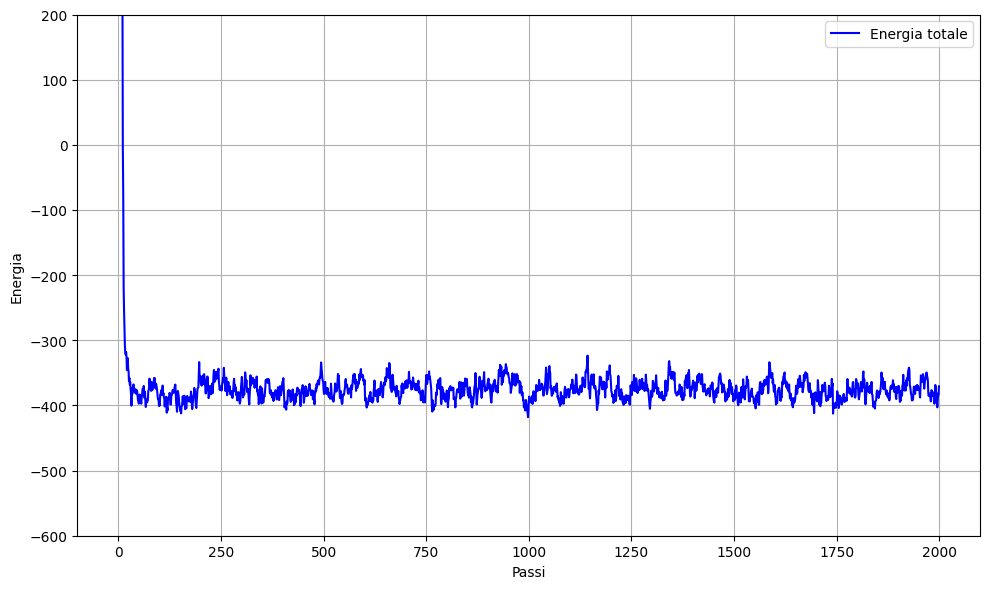

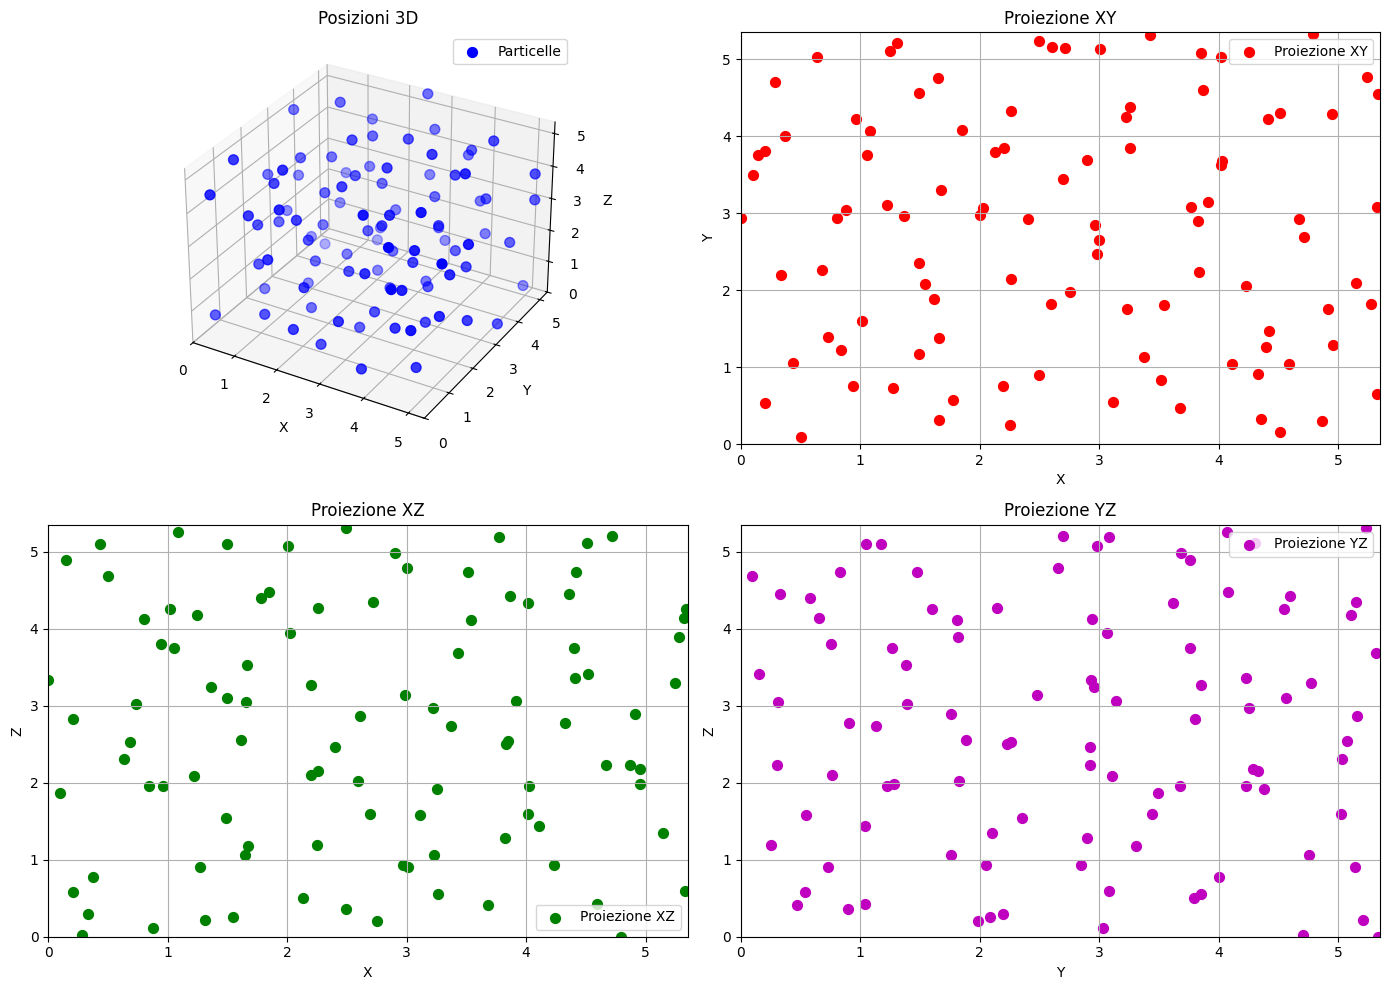

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

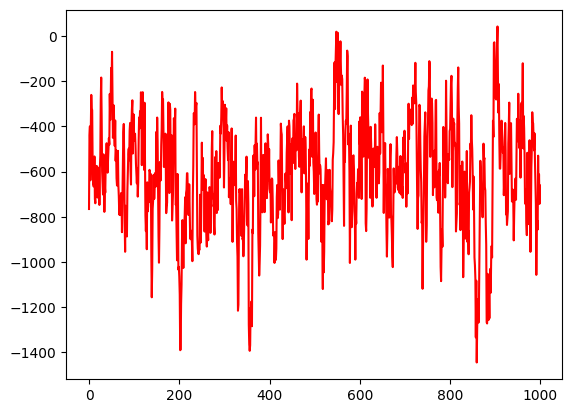

pressione senza tail  2.6296644368527753
pressione con tail  2.257046629942601
Passo 1/2000, Energia: 1659064.143, Accettazione: 0.43
Passo 2/2000, Energia: 72063.207, Accettazione: 0.43
Passo 3/2000, Energia: 22843.379, Accettazione: 0.41
Passo 4/2000, Energia: 19028.945, Accettazione: 0.33
Passo 5/2000, Energia: 8106.608, Accettazione: 0.37
Passo 6/2000, Energia: 1171.970, Accettazione: 0.32
Passo 7/2000, Energia: 801.504, Accettazione: 0.32
Passo 8/2000, Energia: 551.858, Accettazione: 0.29
Passo 9/2000, Energia: 409.164, Accettazione: 0.27
Passo 10/2000, Energia: 299.910, Accettazione: 0.29
Passo 11/2000, Energia: 150.826, Accettazione: 0.19
Passo 12/2000, Energia: -200.834, Accettazione: 0.25
Passo 13/2000, Energia: -239.739, Accettazione: 0.24
Passo 14/2000, Energia: -240.246, Accettazione: 0.18
Passo 15/2000, Energia: -230.994, Accettazione: 0.20
Passo 16/2000, Energia: -253.335, Accettazione: 0.20
Passo 17/2000, Energia: -255.052, Accettazione: 0.23
Passo 18/2000, Energia: -276

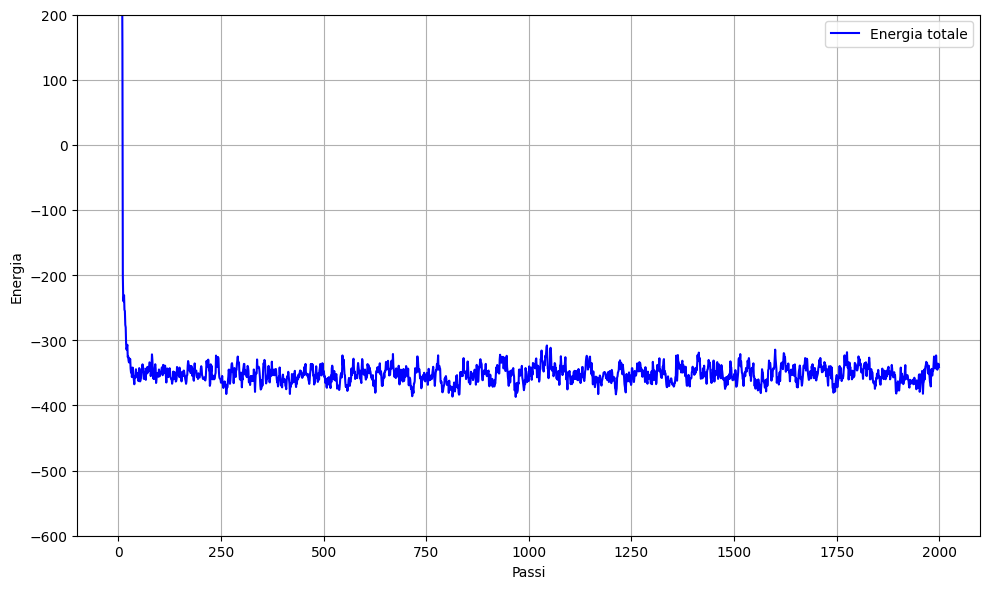

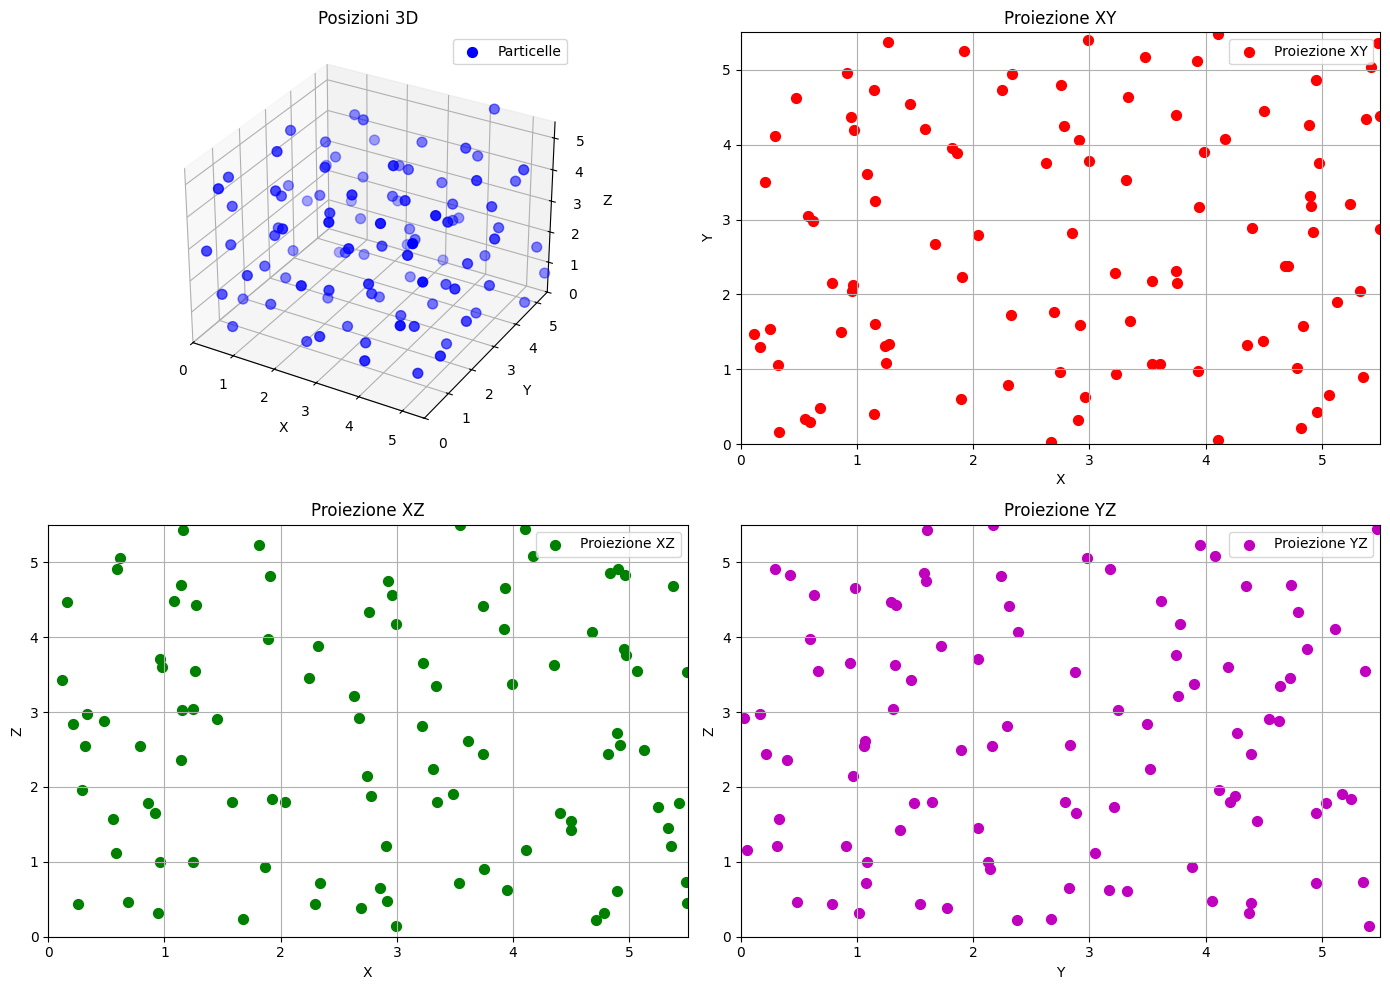

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

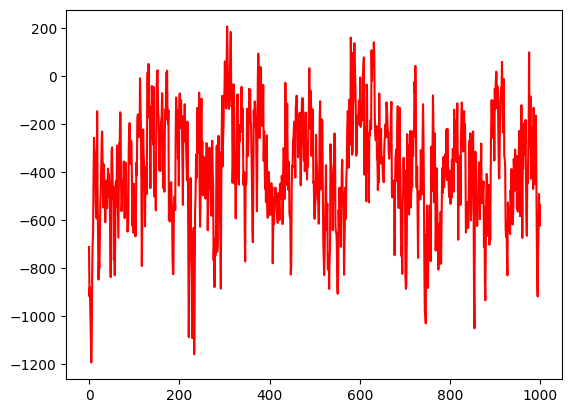

pressione senza tail  1.9784149882672204
pressione con tail  1.687809074070353
Passo 1/2000, Energia: 1575581277455.643, Accettazione: 0.46
Passo 2/2000, Energia: 1902685.605, Accettazione: 0.53
Passo 3/2000, Energia: 1891984.511, Accettazione: 0.39
Passo 4/2000, Energia: 6830.191, Accettazione: 0.39
Passo 5/2000, Energia: 1466.735, Accettazione: 0.40
Passo 6/2000, Energia: 834.954, Accettazione: 0.36
Passo 7/2000, Energia: 317.357, Accettazione: 0.38
Passo 8/2000, Energia: -12.070, Accettazione: 0.35
Passo 9/2000, Energia: -39.342, Accettazione: 0.37
Passo 10/2000, Energia: -249.039, Accettazione: 0.32
Passo 11/2000, Energia: -267.308, Accettazione: 0.35
Passo 12/2000, Energia: -290.654, Accettazione: 0.33
Passo 13/2000, Energia: -289.703, Accettazione: 0.34
Passo 14/2000, Energia: -270.469, Accettazione: 0.29
Passo 15/2000, Energia: -277.521, Accettazione: 0.27
Passo 16/2000, Energia: -276.210, Accettazione: 0.26
Passo 17/2000, Energia: -284.890, Accettazione: 0.36
Passo 18/2000, Ene

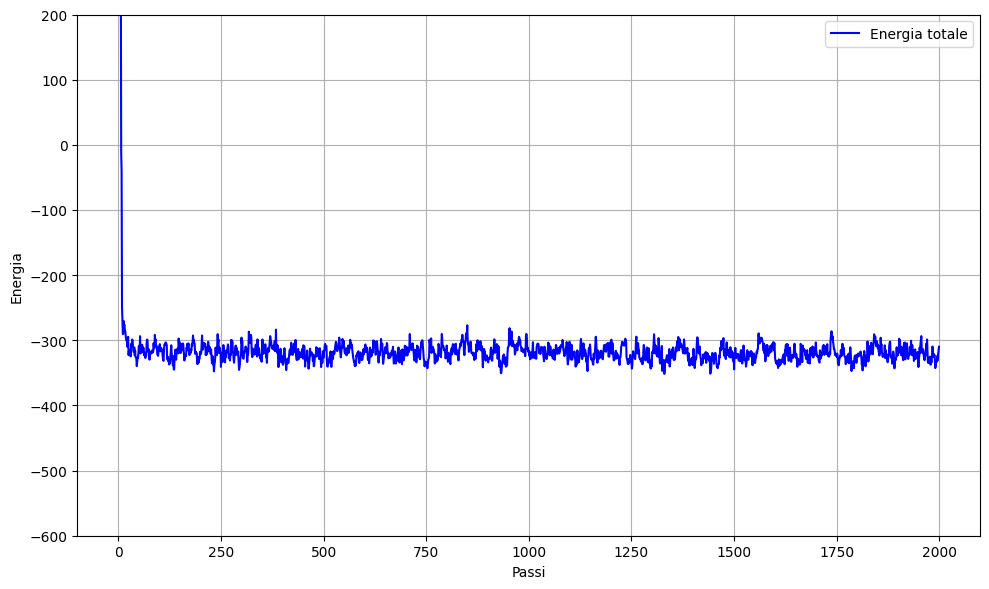

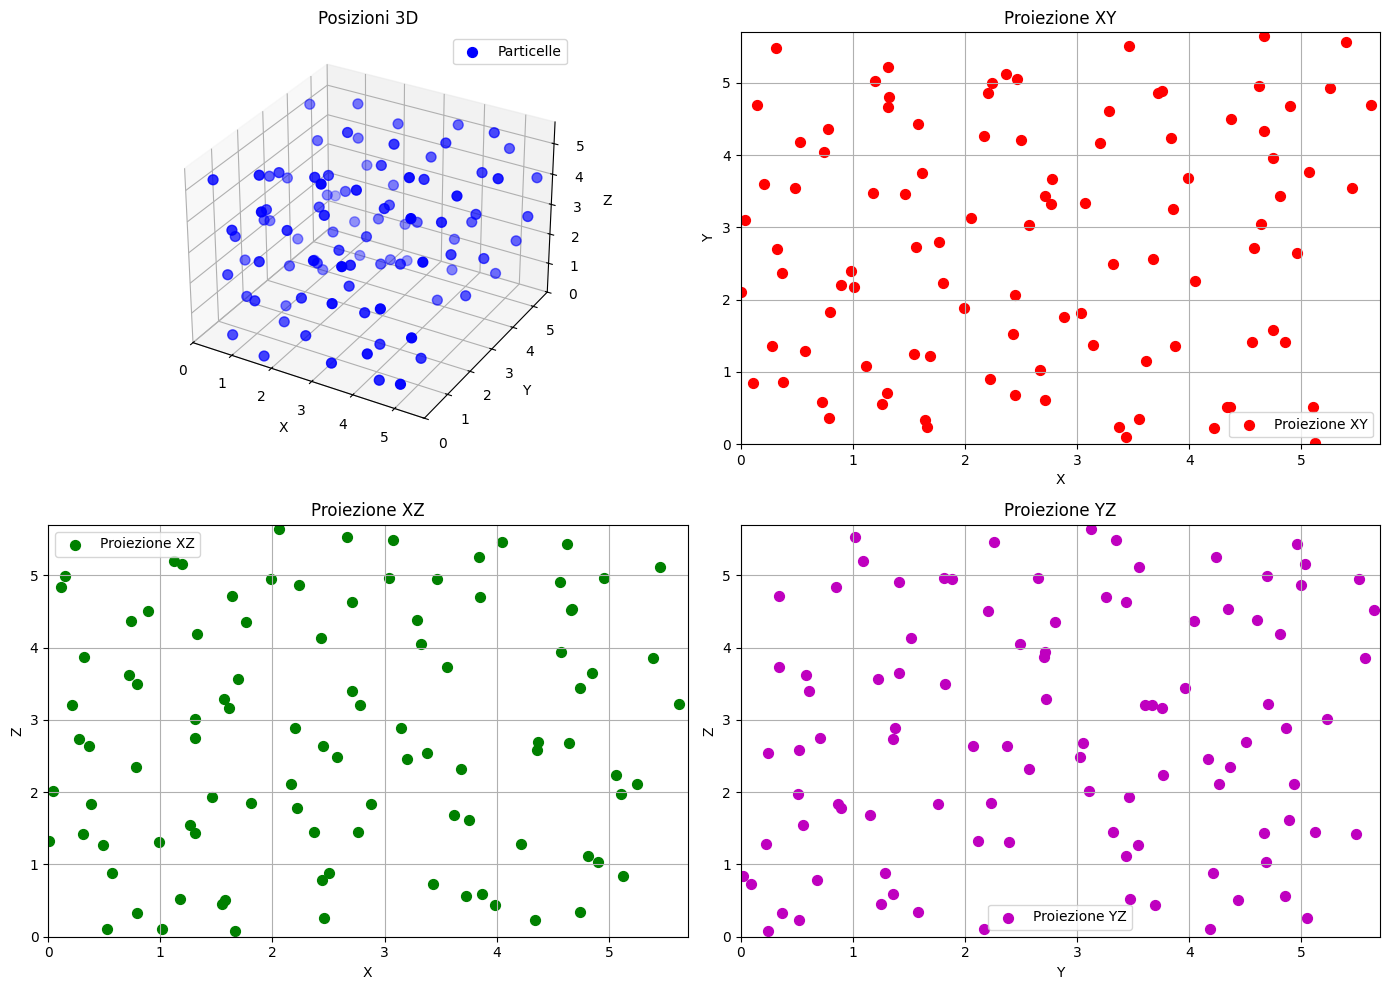

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

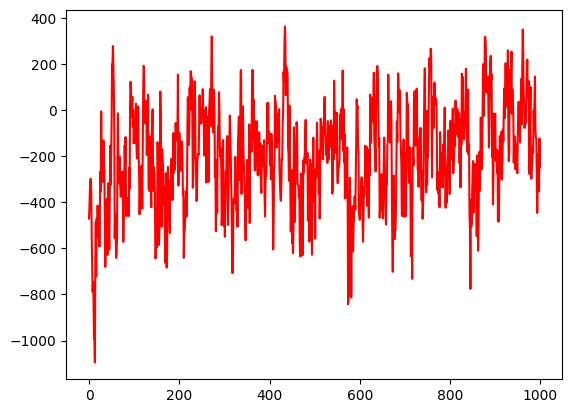

pressione senza tail  1.4434656870268245
pressione con tail  1.2326881797995333
Passo 1/2000, Energia: 204914.233, Accettazione: 0.55
Passo 2/2000, Energia: 48894.543, Accettazione: 0.47
Passo 3/2000, Energia: 25490.874, Accettazione: 0.48
Passo 4/2000, Energia: 4506.409, Accettazione: 0.45
Passo 5/2000, Energia: 3836.613, Accettazione: 0.37
Passo 6/2000, Energia: 1335.375, Accettazione: 0.41
Passo 7/2000, Energia: 1146.742, Accettazione: 0.32
Passo 8/2000, Energia: -77.696, Accettazione: 0.37
Passo 9/2000, Energia: -188.024, Accettazione: 0.41
Passo 10/2000, Energia: -225.869, Accettazione: 0.44
Passo 11/2000, Energia: -248.108, Accettazione: 0.48
Passo 12/2000, Energia: -256.351, Accettazione: 0.33
Passo 13/2000, Energia: -252.344, Accettazione: 0.47
Passo 14/2000, Energia: -259.061, Accettazione: 0.43
Passo 15/2000, Energia: -276.424, Accettazione: 0.42
Passo 16/2000, Energia: -283.368, Accettazione: 0.48
Passo 17/2000, Energia: -291.997, Accettazione: 0.42
Passo 18/2000, Energia: -

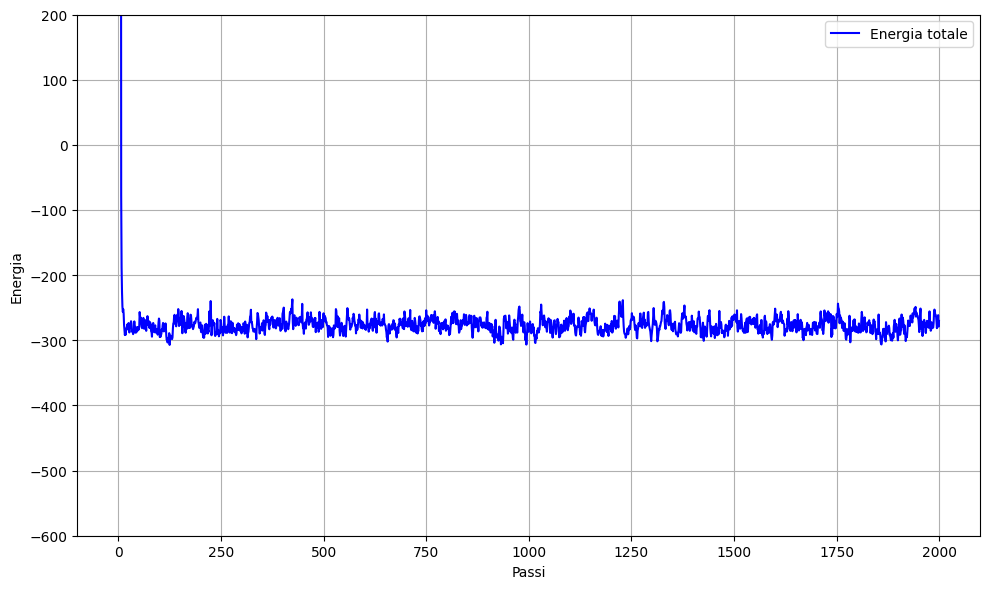

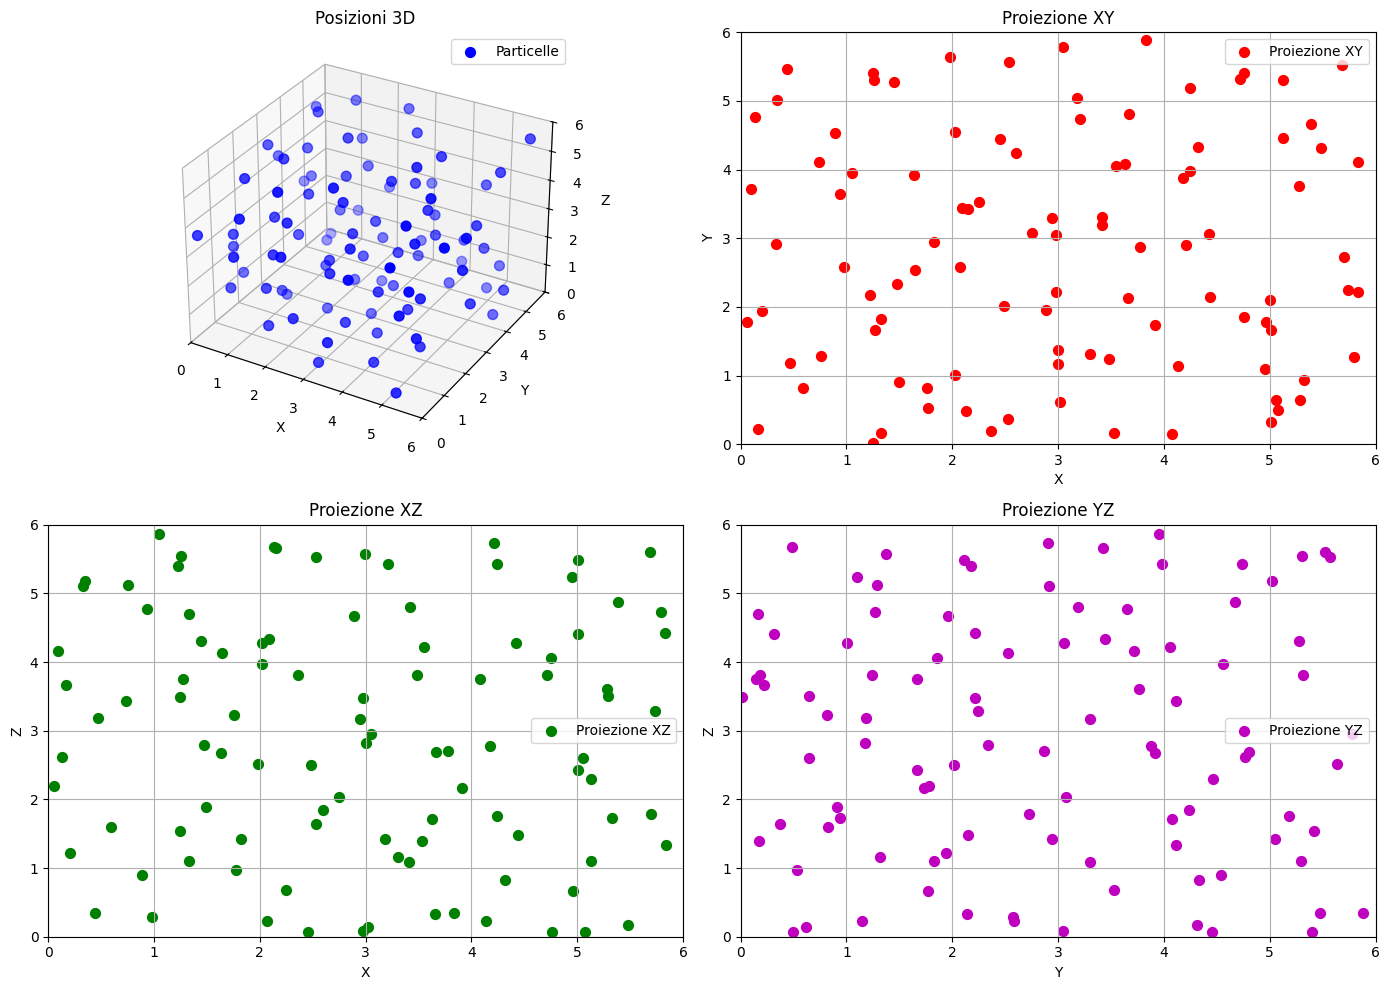

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

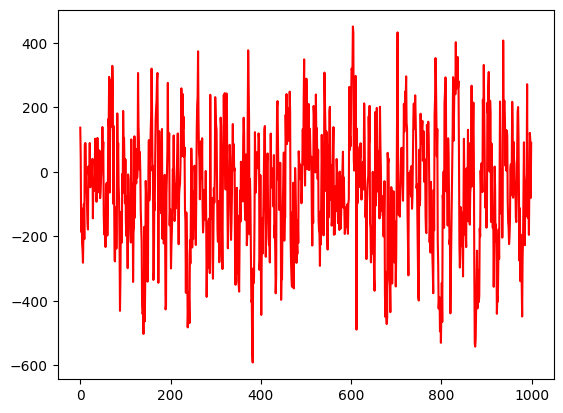

pressione senza tail  1.0072314537709621
pressione con tail  0.8743452201502546
Passo 1/2000, Energia: 20350653.364, Accettazione: 0.48
Passo 2/2000, Energia: 3811733.350, Accettazione: 0.40
Passo 3/2000, Energia: 542823.272, Accettazione: 0.38
Passo 4/2000, Energia: 542374.376, Accettazione: 0.27
Passo 5/2000, Energia: 6239.040, Accettazione: 0.30
Passo 6/2000, Energia: 6229.261, Accettazione: 0.22
Passo 7/2000, Energia: 72.221, Accettazione: 0.25
Passo 8/2000, Energia: -164.242, Accettazione: 0.31
Passo 9/2000, Energia: -173.274, Accettazione: 0.27
Passo 10/2000, Energia: -183.760, Accettazione: 0.21
Passo 11/2000, Energia: -187.990, Accettazione: 0.24
Passo 12/2000, Energia: -185.354, Accettazione: 0.23
Passo 13/2000, Energia: -187.998, Accettazione: 0.25
Passo 14/2000, Energia: -191.856, Accettazione: 0.23
Passo 15/2000, Energia: -171.458, Accettazione: 0.27
Passo 16/2000, Energia: -174.387, Accettazione: 0.24
Passo 17/2000, Energia: -195.556, Accettazione: 0.30
Passo 18/2000, Ener

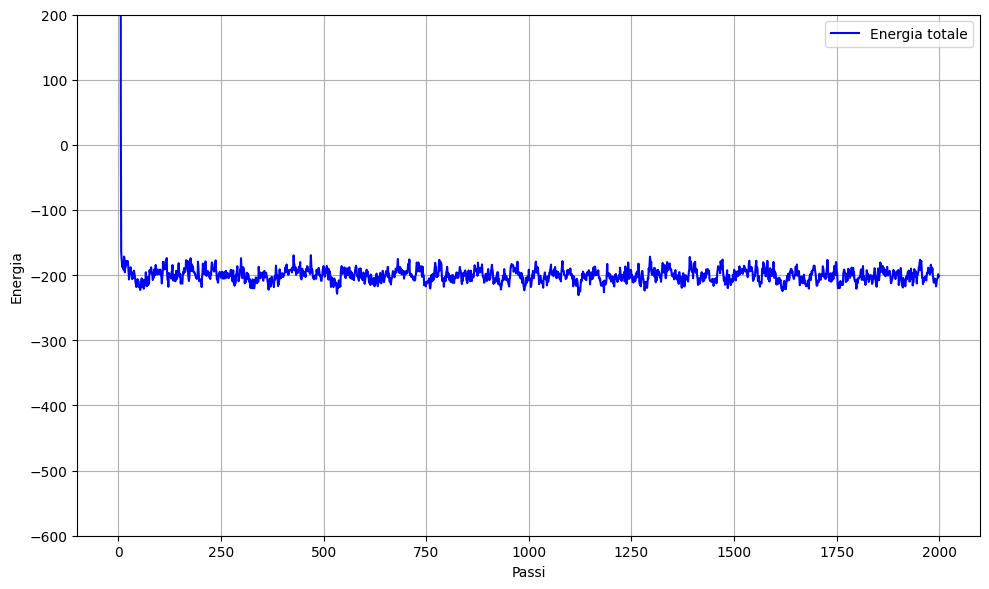

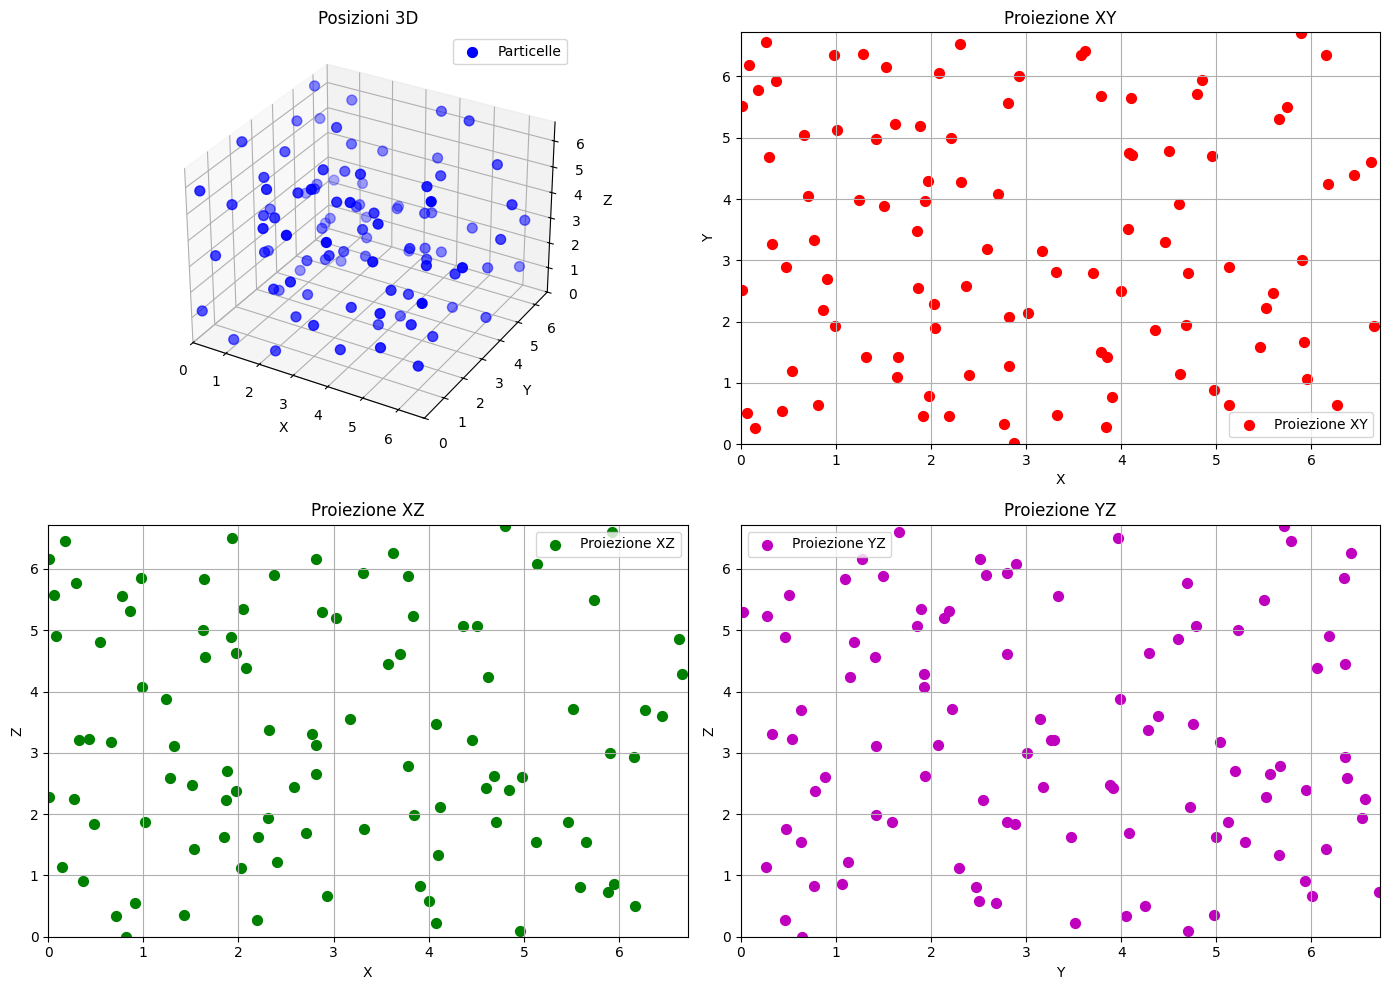

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

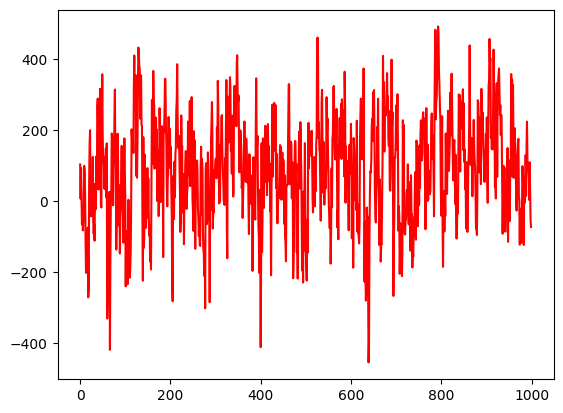

pressione senza tail  0.5640253174360936
pressione con tail  0.5160835688704042
Passo 1/2000, Energia: 11891.775, Accettazione: 0.43
Passo 2/2000, Energia: 1297.068, Accettazione: 0.37
Passo 3/2000, Energia: 79.212, Accettazione: 0.35
Passo 4/2000, Energia: 10.067, Accettazione: 0.33
Passo 5/2000, Energia: -120.024, Accettazione: 0.41
Passo 6/2000, Energia: -159.902, Accettazione: 0.36
Passo 7/2000, Energia: -162.396, Accettazione: 0.38
Passo 8/2000, Energia: -168.249, Accettazione: 0.30
Passo 9/2000, Energia: -172.595, Accettazione: 0.24
Passo 10/2000, Energia: -171.292, Accettazione: 0.30
Passo 11/2000, Energia: -165.397, Accettazione: 0.30
Passo 12/2000, Energia: -159.329, Accettazione: 0.25
Passo 13/2000, Energia: -166.515, Accettazione: 0.40
Passo 14/2000, Energia: -174.720, Accettazione: 0.28
Passo 15/2000, Energia: -172.587, Accettazione: 0.42
Passo 16/2000, Energia: -171.852, Accettazione: 0.29
Passo 17/2000, Energia: -173.404, Accettazione: 0.35
Passo 18/2000, Energia: -171.94

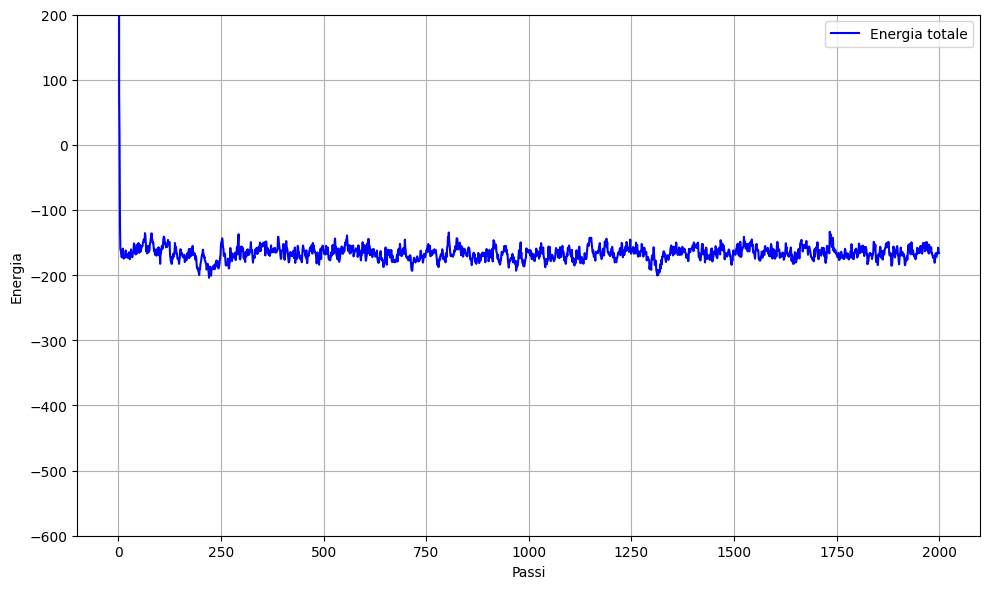

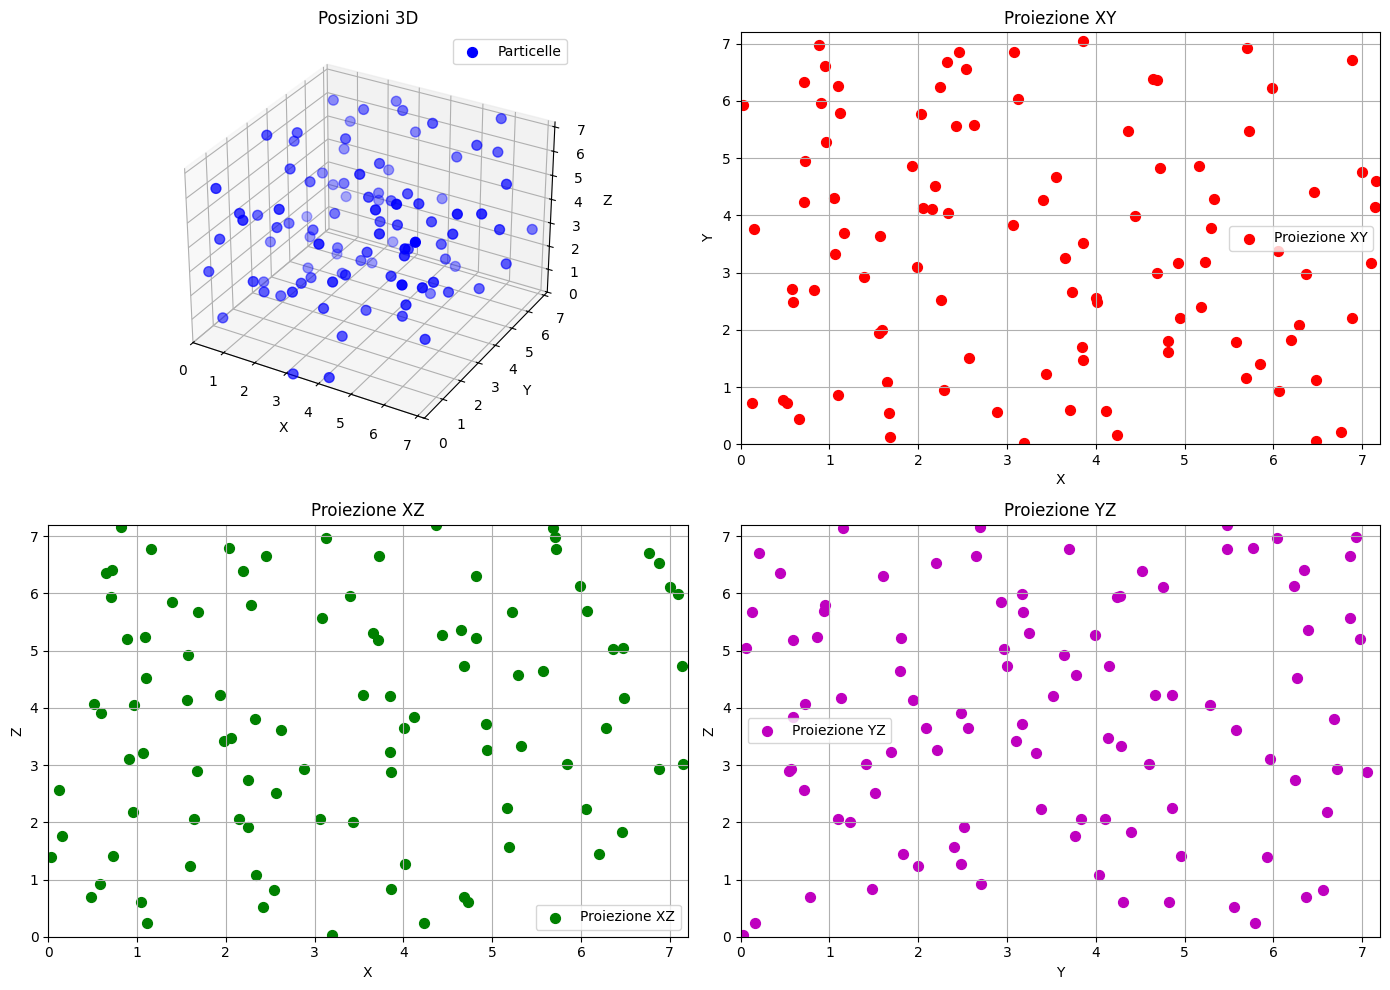

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

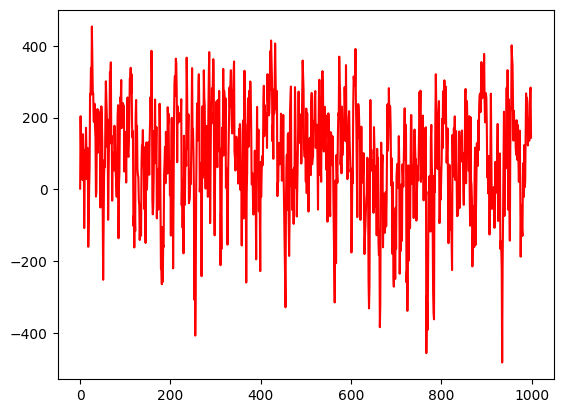

pressione senza tail  0.4570463493974467
pressione con tail  0.43127642815430456
Passo 1/2000, Energia: 87652.537, Accettazione: 0.60
Passo 2/2000, Energia: 14680.263, Accettazione: 0.41
Passo 3/2000, Energia: 78.048, Accettazione: 0.30
Passo 4/2000, Energia: 80.732, Accettazione: 0.48
Passo 5/2000, Energia: 79.313, Accettazione: 0.39
Passo 6/2000, Energia: -123.104, Accettazione: 0.44
Passo 7/2000, Energia: -125.873, Accettazione: 0.37
Passo 8/2000, Energia: -126.429, Accettazione: 0.42
Passo 9/2000, Energia: -133.415, Accettazione: 0.44
Passo 10/2000, Energia: -136.897, Accettazione: 0.35
Passo 11/2000, Energia: -135.622, Accettazione: 0.41
Passo 12/2000, Energia: -134.630, Accettazione: 0.40
Passo 13/2000, Energia: -131.027, Accettazione: 0.35
Passo 14/2000, Energia: -129.957, Accettazione: 0.37
Passo 15/2000, Energia: -141.291, Accettazione: 0.37
Passo 16/2000, Energia: -144.965, Accettazione: 0.34
Passo 17/2000, Energia: -148.324, Accettazione: 0.33
Passo 18/2000, Energia: -140.50

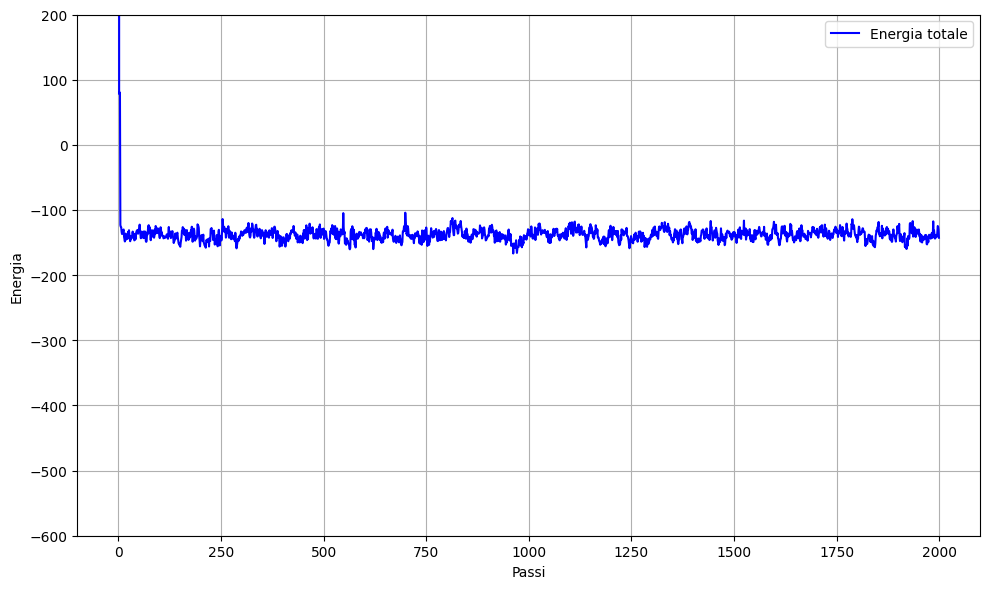

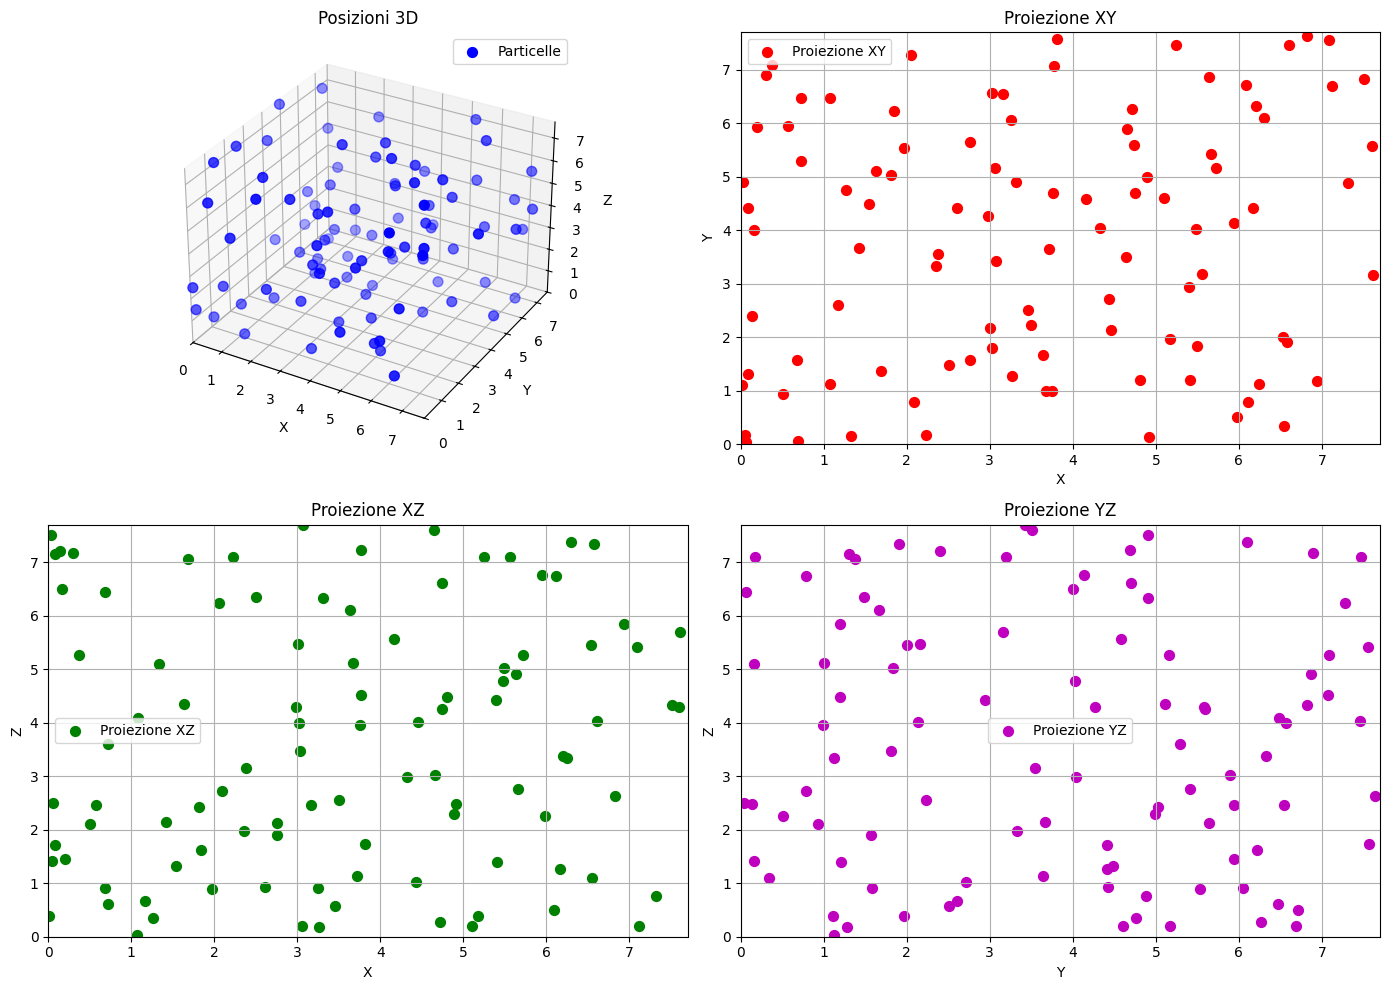

passo 1/1000
passo 2/1000
passo 3/1000
passo 4/1000
passo 5/1000
passo 6/1000
passo 7/1000
passo 8/1000
passo 9/1000
passo 10/1000
passo 11/1000
passo 12/1000
passo 13/1000
passo 14/1000
passo 15/1000
passo 16/1000
passo 17/1000
passo 18/1000
passo 19/1000
passo 20/1000
passo 21/1000
passo 22/1000
passo 23/1000
passo 24/1000
passo 25/1000
passo 26/1000
passo 27/1000
passo 28/1000
passo 29/1000
passo 30/1000
passo 31/1000
passo 32/1000
passo 33/1000
passo 34/1000
passo 35/1000
passo 36/1000
passo 37/1000
passo 38/1000
passo 39/1000
passo 40/1000
passo 41/1000
passo 42/1000
passo 43/1000
passo 44/1000
passo 45/1000
passo 46/1000
passo 47/1000
passo 48/1000
passo 49/1000
passo 50/1000
passo 51/1000
passo 52/1000
passo 53/1000
passo 54/1000
passo 55/1000
passo 56/1000
passo 57/1000
passo 58/1000
passo 59/1000
passo 60/1000
passo 61/1000
passo 62/1000
passo 63/1000
passo 64/1000
passo 65/1000
passo 66/1000
passo 67/1000
passo 68/1000
passo 69/1000
passo 70/1000
passo 71/1000
passo 72/1000
p

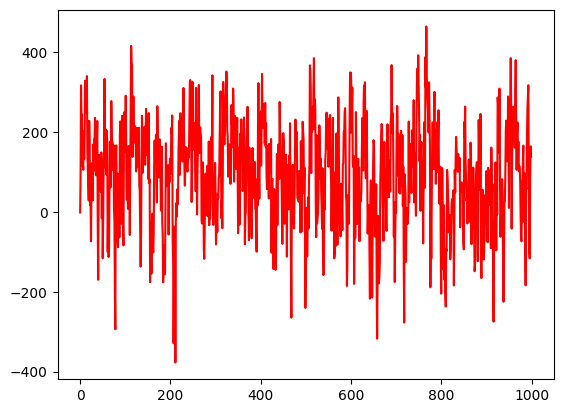

pressione senza tail  0.3702905709964328
pressione con tail  0.35620633976944593
Passo 1/2000, Energia: 4775062.924, Accettazione: 0.49
Passo 2/2000, Energia: 16862.688, Accettazione: 0.50
Passo 3/2000, Energia: -3.635, Accettazione: 0.46
Passo 4/2000, Energia: -13.832, Accettazione: 0.41
Passo 5/2000, Energia: -16.200, Accettazione: 0.38
Passo 6/2000, Energia: -14.375, Accettazione: 0.39
Passo 7/2000, Energia: -16.687, Accettazione: 0.33
Passo 8/2000, Energia: -6.665, Accettazione: 0.53
Passo 9/2000, Energia: -93.610, Accettazione: 0.50
Passo 10/2000, Energia: -102.668, Accettazione: 0.33
Passo 11/2000, Energia: -97.986, Accettazione: 0.49
Passo 12/2000, Energia: -104.350, Accettazione: 0.39
Passo 13/2000, Energia: -108.987, Accettazione: 0.42
Passo 14/2000, Energia: -120.096, Accettazione: 0.42
Passo 15/2000, Energia: -109.114, Accettazione: 0.39
Passo 16/2000, Energia: -104.443, Accettazione: 0.37
Passo 17/2000, Energia: -103.983, Accettazione: 0.39
Passo 18/2000, Energia: -96.648, 

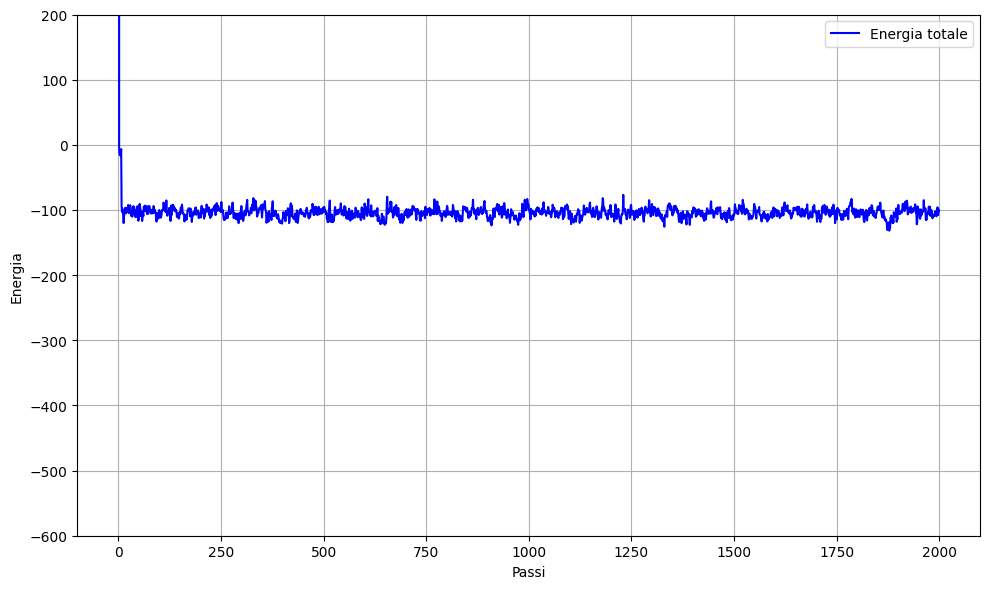

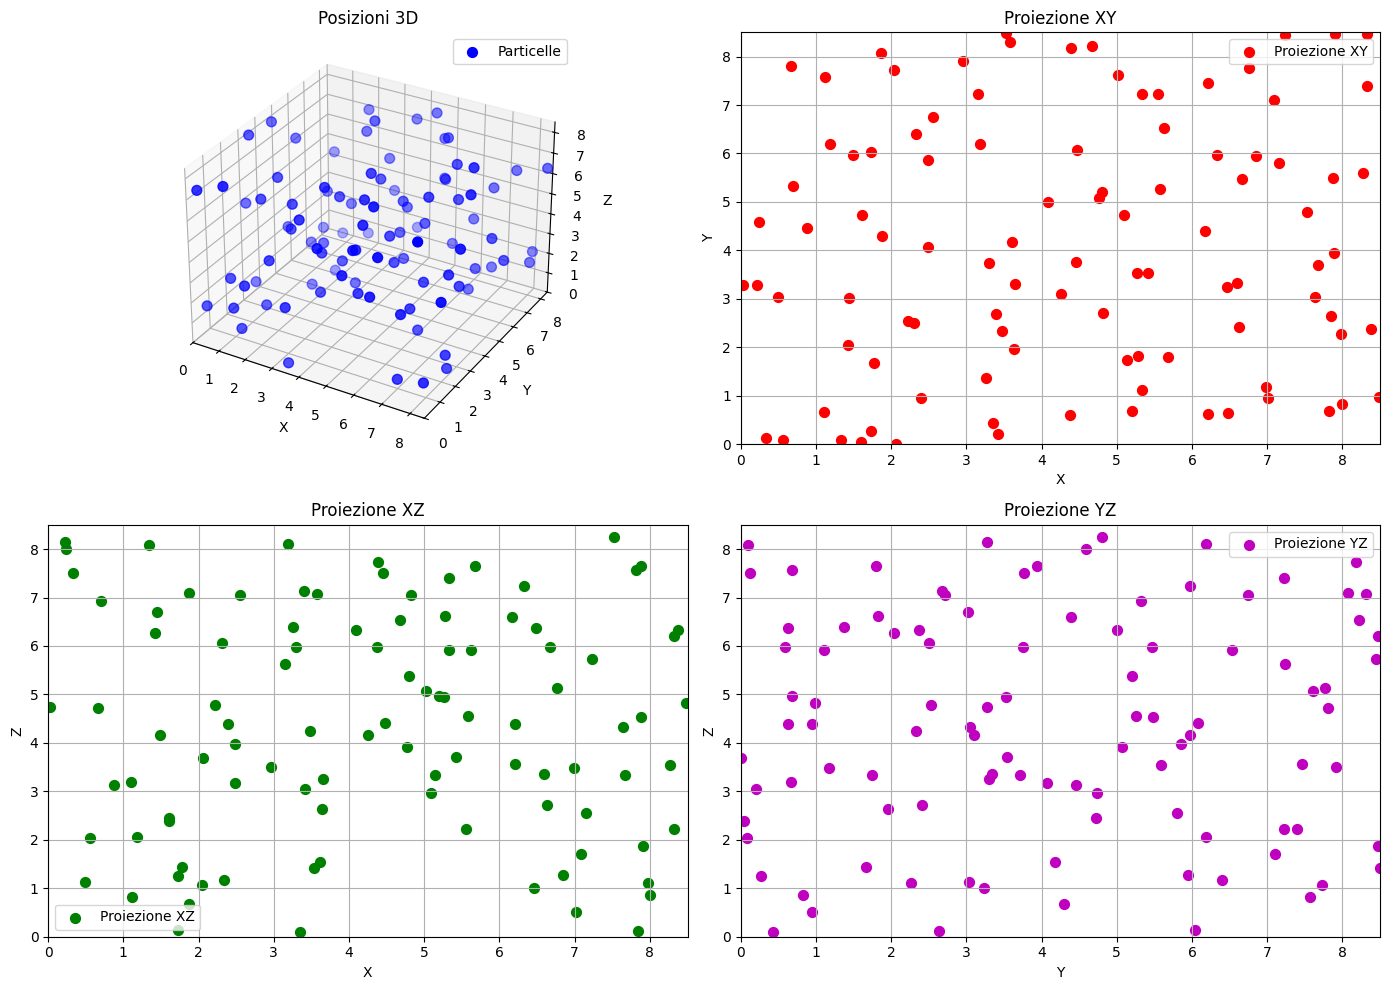

ValueError: unable to broadcast argument 1 to output array
File "C:\Users\Sofia\AppData\Local\Temp\ipykernel_744\1330550979.py", line 1, 

In [12]:
steps = 2000
pressures = []
densities = [] 
err_pressures = []

# Different sizes of the box are considered (to test different densities). Simulation is run for each size. Then after equilibration another small run is done 
# the small run is used to compute the average value of the virial and the correspondent pressure. 
for k in range(len(sizes)):    
  vir = np.zeros(1000)
  sigma_cut = sizes[k] / 2
  rho = N / (sizes[k])**3
  p_tail = (16 / 3) * math.pi * rho**2 * ((2 / 3) * (sigma / sigma_cut)**9 - (sigma / sigma_cut)**3)
 
# Simulation is done: final positions, final energies (just LJ contribution), final distances among particles are returned     
  energies, distances, positions = run_simulation(T_high, steps, sizes[k], sigma_cut)

  # energy for each size of the box is plotted 
  plot_energy(energies) 
  plot_positions_with_projections(positions, sizes[k])
# AFTER A FIRST SIMULATION 
  # array of virials 
  virials = continue_simu_P_mean(positions, distances, T_high, 1000, sizes[k], sigma_cut)
  plt.plot(range(1000), virials, label='Virial', color='red')
  plt.show()
  
  #average value of the virial and its uncertainty
  forces = np.average(virials)
  sigma_f = np.sqrt(np.average(virials**2) - forces**2) 
  
  # Now I compute the correspondent pressure
  P = equation_state(rho, forces, sizes[k], T_high)
  print('pressione senza tail ', P)

  # Adding tail
  P_final = P + p_tail
  print('pressione con tail ', P_final)

  # error computed from the one of the average of the virial
  sigma_p = (1/3) * (sigma_f) / (sizes[k]**3)   
# FINAL LIST OF PRESSURES AND DENSITIES
  pressures.append(P_final)
  densities.append(rho)
  err_pressures.append(sigma_p)
  #%lprun -f run_simulation -f displace run_simulation(0.9, steps, sizes[k], sigma_cut)

  


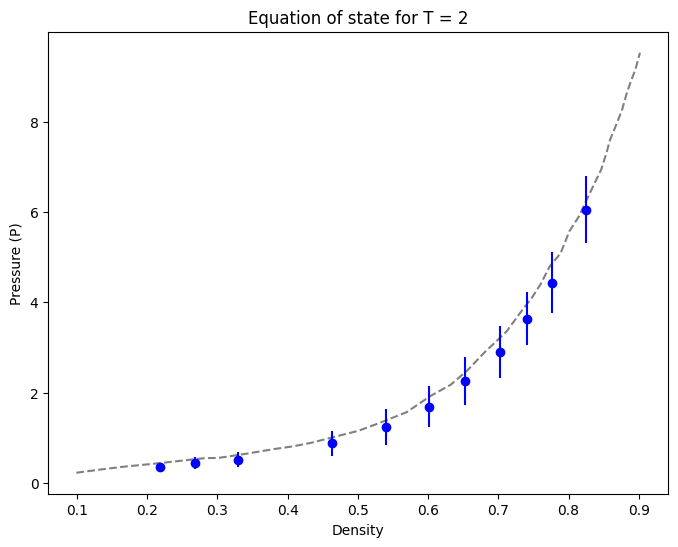

In [ ]:
# FINAL PLOT OF THE EQUATION OF STATE PRESSURE vs DENSITY
#plt.figure(figsize=(10, 8))
data = np.loadtxt('LJ_T2.dat')  

x = data[:, 0]  
y = data[:, 1] 

plt.figure(figsize=(8, 6))
plt.plot(x, y, linestyle='--', color='grey', label='Dati')
plt.errorbar(densities, pressures, yerr = err_pressures, marker='o', linestyle='none', color='blue')
plt.title('Equation of state for T = 2')
plt.
plt.xlabel('Density')
plt.ylabel('Pressure (P)')
plt.show()

In [18]:
pressures2 = np.load("pressure.npy")
densities2 = np.load("density.npy")
err_pressures2 = np.load("error_p.npy")

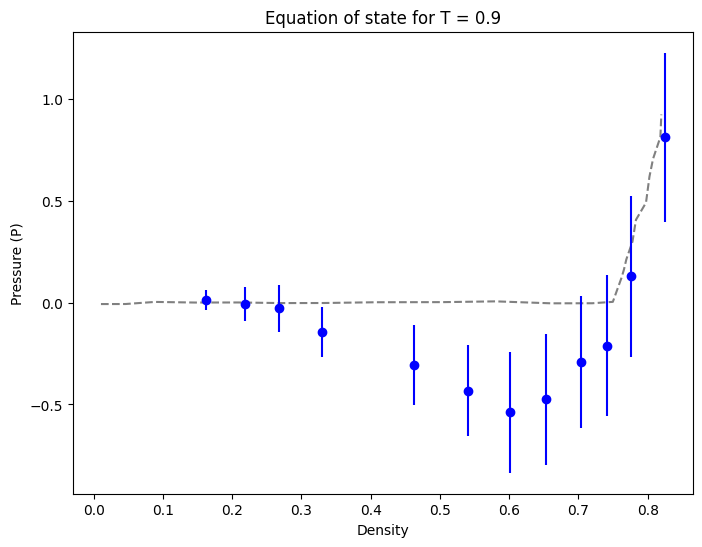

In [23]:
# FINAL PLOT OF THE EQUATION OF STATE PRESSURE vs DENSITY
#plt.figure(figsize=(10, 8))
data = np.loadtxt('LJ_T09.dat')  

x = data[:, 0]  
y = data[:, 1] 

plt.figure(figsize=(8, 6))
plt.plot(x, y, linestyle='--', color='grey', label='Dati')
plt.errorbar(densities2, pressures2, yerr = err_pressures2, marker='o', linestyle='none', color='blue')
plt.title('Equation of state for T = 0.9')

plt.xlabel('Density')
plt.ylabel('Pressure (P)')
plt.show()

In [31]:
#np.save("pressure.npy", pressures)
#np.save("density.npy", densities)
#np.save("error_p.npy", err_pressures)

DATI 

In [ ]:
data = np.loadtxt('LJ_T09.dat')  

x = data[:, 0]  
y = data[:, 1] 

plt.figure(figsize=(8, 6))
plt.plot(x, y, marker='o', linestyle='-', color='grey', label='Dati')
plt.xlabel('density')
plt.ylabel('pressure')
plt.title('Rappresentazione dei dati')
plt.legend()
plt.grid(True)
plt.show()
print(x)


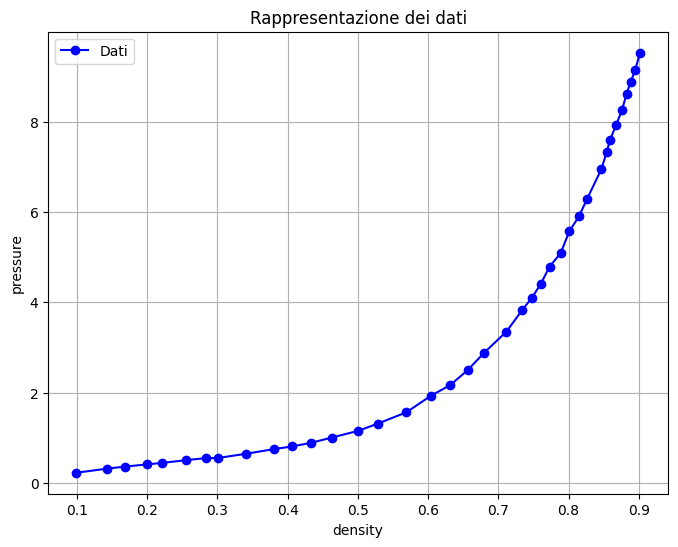

In [8]:
data2 = np.loadtxt('LJ_T2.dat')  

x = data2[:, 0]  
y = data2[:, 1] 

plt.figure(figsize=(8, 6))
plt.plot(x, y, marker='o', linestyle='-', color='blue', label='Dati')
plt.xlabel('density')
plt.ylabel('pressure')
plt.title('Rappresentazione dei dati')
plt.legend()
plt.grid(True)
plt.show()